# Khớp tầng — định vị nguyên nhân trong hệ microservice

**Cơ sở lý thuyết và toàn bộ thực nghiệm, trong một notebook.**
Bản trình bày cho lab. Mọi con số trong notebook này được **tính lại tại chỗ** từ CSV kết
quả trong `data/processed/scm_results/`, và mỗi CSV truy được về **một script** trong
`experiments/chua_phan_loai/` (danh sách lệnh ở Phần 7).

---

## Phát hiện, một câu

> **Độ chính xác định vị nguyên nhân bị quyết định bởi TẦNG metric được soi, không bởi
> thuật toán xếp hạng — và tầng đúng là tầng mà nguyên nhân nằm.**

## Bằng chứng mạnh nhất, một bảng

Cùng 90 lần tiêm lỗi, cùng đáp án, cùng cửa sổ trước/sau. Chỉ đổi **hai núm**:

| ứng viên | tầng metric | thống kê | top‑1 |
|---|---|---|---|
| 7 service app | **chỉ `_cpu`** | BARO (FSE'24) | **98,3%** |
| 7 service app | **chỉ `_cpu`** | MEANSHIFT | **98,3%** |
| ~15 service | mọi cột metric | BARO (FSE'24) | **11,7%** |

**Chênh 86,6 điểm, hoàn toàn do một lựa chọn cấu hình.** Trên tầng đúng, hai thống kê
bằng nhau *tuyệt đối*. Thống kê chỉ quan trọng khi tầng đã sai.

## Lý thuyết khép kín — ba vị trí nguyên nhân, ba vị trí tín hiệu

| nguyên nhân nằm ở | tín hiệu lớn nhất ở | tầng cần soi | đơn vị quy gán | độ chính xác |
|---|---|---|---|---|
| **node**, tầng tài nguyên | chính node đó | `cpu` | node | **96,7–98,3%** top‑1 |
| **node**, tầng nhu cầu | hậu duệ của node đó | `workload` | node | ρ **+0,77 / +0,79** |
| **cạnh** giữa hai node | **node quan sát cạnh** (thượng nguồn) | `latency-50` | **đường** | **80,0 / 90,0 / 96,7%** |

Và một phát biểu chính xác hơn "mỗi nguyên nhân một tầng" — ba mức, suy trực tiếp từ
d‑separation (§2.4b): tầng **chứa** nguyên nhân cao nhất; tầng **hậu duệ** của nó vẫn có
tín hiệu nhưng loãng hơn; tầng **không phải hậu duệ** đúng **mức ngẫu nhiên**.

## Quy mô thực nghiệm

**3 hệ thống × 90 kịch bản = 270 ca lỗi thật** — đúng trọn bộ RCAEval RE2, bằng quy mô
của BARO (FSE'24) và của chính bài báo benchmark.

| | Sock Shop | Online Boutique | Train Ticket |
|---|---|---|---|
| service ứng dụng (tầng `workload`) | 7 | 11 | 28 |
| cột ứng viên ở tầng `cpu` (kể cả hạ tầng) | 15 | 11 | 68 |
| service **bị tiêm lỗi** | **5** | **5** | **5** |
| kịch bản × lần lặp | 30 × 3 | 30 × 3 | 30 × 3 |

Số ứng viên **khác nhau theo tầng**, nên mức sàn ngẫu nhiên cũng khác nhau theo tầng — mọi
kiểm định trong notebook này dùng mức sàn **của đúng tầng đó**, không dùng một con số chung.

## Notebook này đi theo thứ tự nào

Phần 3 (dữ liệu) **đứng trước** Phần 2b (mô hình) về mặt lập luận: tiền đề thực nghiệm được
đo từ **dữ liệu thô**, độc lập hoàn toàn với đồ thị nhân quả. Lý thuyết chỉ áp vào **sau**
khi tiền đề đó được đo. Trình bày theo thứ tự lý‑thuyết‑trước sẽ che mất bước đó và bị bắt
ngay (xem §2.5).


In [1]:
import json, os, sys, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest, spearmanr, pearsonr, wilcoxon

ROOT = Path.cwd()
while not (ROOT / 'src').exists():            # notebook nam trong notebooks/ -> leo len goc repo
    ROOT = ROOT.parent
sys.path[:0] = [str(ROOT / 'src' / 'scm'), str(ROOT / 'src' / 'agents'), str(ROOT / 'src')]

RES = ROOT / 'data' / 'processed' / 'scm_results'
RAW = ROOT / 'data' / 'raw'
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'font.size': 9, 'axes.titlesize': 10})
try:
    display
except NameError:                              # chay ngoai Jupyter (kiem thu CI) -> in thuong
    display = print

RESOURCE = ['cpu', 'mem', 'disk', 'socket']    # nhom loi TAI NGUYEN
NETWORK  = ['delay', 'loss']                   # nhom loi MANG
LAYERS   = ['workload', 'cpu', 'latency-50']
TEN_TANG = {'workload': 'nhu cau', 'cpu': 'tai nguyen', 'latency-50': 'do tre'}

def nap(ten):
    """Doc mot CSV ket qua; bao ro neu thieu (kem lenh sinh lai)."""
    p = RES / ten
    if not p.exists():
        raise FileNotFoundError(f'thieu {p} -- xem Phan 7 de biet lenh sinh lai')
    return pd.read_csv(p)

print('goc repo :', ROOT)
print('CSV ket qua co san:', len(list(RES.glob("rq6_*.csv"))), 'file')


goc repo : /Users/ngkky/NCKH/NCKH
CSV ket qua co san: 60 file


---

# Phần 1 — Vấn đề

## 1.1 Bài toán

Một hệ microservice có hàng chục service. Khi có sự cố, telemetry ghi lại hàng trăm chuỗi
thời gian: workload, CPU, memory, độ trễ — mỗi service một bộ. Câu hỏi của **định vị
nguyên nhân gốc** (root cause analysis, RCA): *service nào gây ra sự cố?*

Văn liệu RCA microservice năm năm qua trả lời câu hỏi đó bằng cách **đổi thuật toán xếp
hạng**: khám phá cấu trúc nhân quả (CIRCA, RCD, MicroCause), quy gán Shapley can thiệp
(Budhathoki et al., ICML 2022), thống kê bền (BARO, FSE'24), học biểu diễn (CausalRCA,
RUN). Bộ benchmark RCAEval (2024) tập hợp **15 baseline** như vậy.

## 1.2 Vì sao đó là câu hỏi sai — hoặc ít nhất là chưa đủ

Mọi phương pháp trong danh sách trên đều phải trả lời một câu hỏi **trước** câu hỏi thuật
toán: **đọc cột metric nào?** Và câu đó hầu như không bao giờ được đặt thành câu hỏi
nghiên cứu. Nó nằm trong phần "tiền xử lý", một dòng cấu hình.

Phát hiện của chúng tôi là: **lựa chọn một dòng đó quyết định nhiều hơn toàn bộ phần thuật
toán.** Và nó không phải chuyện tuning — có một **nguyên lý** nói trước được tầng nào đúng,
cho từng loại nguyên nhân. Nguyên lý đó là nội dung Phần 2.

> **Hệ quả về cách đọc văn liệu.** Nếu đúng, thì một phần những "thất bại của phương pháp X"
> trong văn liệu là **lệch tầng**, không phải khuyết điểm của X. Và một phần những "cải tiến"
> là cải tiến *cấu hình tầng* được báo nhầm thành cải tiến *thuật toán*. Phần 4 kiểm điều này
> trực tiếp trên một baseline đã xuất bản.


---

# Phần 2 — Cơ sở lý thuyết

## 2.1 Ba tầng quan sát, bốn loại cạnh

Mô hình nhân quả của một hệ microservice, dưới dạng **SCM** (structural causal model,
Pearl 2009), có node là `<service>_<metric>`. Các node đó chia thành **ba tầng**:

| tầng | cột | nghĩa vật lý |
|---|---|---|
| **nhu cầu** (demand) | `<svc>_workload` | số request mỗi giây tới service |
| **tài nguyên** (resource) | `<svc>_cpu`, `<svc>_mem` | tài nguyên service tiêu thụ |
| **độ trễ** (latency) | `<svc>_latency-50` | thời gian phục vụ |

Điều quyết định là: **cạnh nào được phép tồn tại**. Bảng mẫu cạnh dưới đây là một
*prohibited‑edge constraint* theo nghĩa của CausIL — mọi dạng cạnh không khai báo đều **bị
cấm do xây dựng**, không phải do học ra.


In [2]:
import scm_graph_builder as GB

T = pd.DataFrame([dict(ten=t.name, cha=t.parent_metric, con=t.child_metric,
                       pham_vi=t.scope, chieu=t.direction or '-',
                       hoc=('HOC' if t.learned else 'cau truc'))
                  for t in GB.DEFAULT_EDGE_TEMPLATES])
TANG = {('workload','workload'): 'TRONG tang nhu cau',
        ('workload','cpu'):      'nhu cau -> tai nguyen',
        ('workload','mem'):      'nhu cau -> tai nguyen',
        ('workload','latency-50'):'nhu cau -> do tre',
        ('cpu','cpu'):           'TRONG tang tai nguyen  (TRANH CHAP)',
        ('latency-50','latency-50'): 'TRONG tang do tre  (lan truyen nguoc)'}
T['y nghia tang'] = [TANG[(a, b)] for a, b in zip(T.cha, T.con)]
display(T)
print(f'\nKHONG co mau canh `cpu -> workload` -> do thi KHONG THE chua canh do. '
      f'\nDay la gia dinh DO XAY DUNG, khong phai phat hien. Xem muc 2.5.')


,ten,cha,con,pham_vi,chieu,hoc,y nghia tang
0,tier1_workload_propagation,workload,workload,inter,forward,cau truc,TRONG tang nhu cau
1,tier2_cpu,workload,cpu,intra,-,cau truc,nhu cau -> tai nguyen
2,tier2_mem,workload,mem,intra,-,cau truc,nhu cau -> tai nguyen
3,tier2_latency,workload,latency-50,intra,-,cau truc,nhu cau -> do tre
4,cpu_backpressure,cpu,cpu,inter,forward,HOC,TRONG tang tai nguyen (TRANH CHAP)
5,latency_backprop_causil,latency-50,latency-50,inter,reverse,HOC,TRONG tang do tre (lan truyen nguoc)



KHONG co mau canh `cpu -> workload` -> do thi KHONG THE chua canh do. 
Day la gia dinh DO XAY DUNG, khong phai phat hien. Xem muc 2.5.


Bốn loại cạnh, đọc theo tầng:

| cạnh | dạng | nghĩa |
|---|---|---|
| **lan truyền nhu cầu** | `workload → workload` | request đi theo chuỗi gọi |
| **chuyển hoá cục bộ** | `workload → cpu / mem / latency` | mỗi request tốn tài nguyên, mất thời gian |
| **tranh chấp** | **`cpu → cpu`** | service A nghẽn làm chậm B *dù request của B không đổi* |
| **lan truyền độ trễ** | **`latency → latency`** (ngược) | callee chậm làm caller chậm |

Điểm mấu chốt: **mỗi loại cạnh nằm trong một tầng, hoặc đi một chiều giữa hai tầng.** Không
có cạnh nào đi ngược từ tài nguyên về nhu cầu. Nên mỗi loại nguyên nhân sinh tín hiệu **trên
tầng của nó**, rồi lan **trong** tầng đó.


## 2.2 Định nghĩa: đáp ứng tầng

Với nguyên nhân tại service $x$ và tầng $L \in \{\texttt{workload}, \texttt{cpu}, \texttt{latency-50}\}$:

$$
r_L(x) \;=\; \frac{\bigl|\,\mathbb{E}[L_x \mid \text{nguyên nhân}] \;-\; \mathbb{E}[L_x]\,\bigr|}{\sigma(L_x)}
$$

Đọc: *tín hiệu của nguyên nhân, đo trên tầng $L$ tại chính service $x$, chuẩn hoá theo độ
nhiễu nền của tầng đó.* Đây là một lượng **đo được từ dữ liệu thô** — chỉ cần hai cửa sổ
trước/sau và một cột metric. Không cần đồ thị, không cần mô hình.

## 2.3 Mệnh đề 1 (dạng độ lớn)

> Tầng $L$ mang thông tin định vị $x$ **khi và chỉ khi** $r_L(x)$ vượt khỏi độ trải của
> $r_L(v)$ trên các $v \neq x$. Trong một SCM tuyến tính, $r_L(x)$ là tổng tích hệ số theo
> **mọi đường có hướng** từ điểm can thiệp tới $L_x$; một tầng **không có đường nào** tới
> điểm can thiệp có $r_L(x) = 0$, và một bộ xếp hạng đọc tầng đó đạt **đúng mức ngẫu nhiên**.

**Chứng minh, hai trường hợp.**

*(a) Can thiệp cứng* ($\mathrm{do}(X{=}x)$). Pearl (2009), §3.4, Theorem 3.4.1, **Rule 3**
của do‑calculus:

$$
P\bigl(y \mid \mathrm{do}(x), \mathrm{do}(z), w\bigr) = P\bigl(y \mid \mathrm{do}(x), w\bigr)
\quad\text{nếu}\quad (Y \perp\!\!\!\perp Z \mid X, W)_{G_{\overline{X}\,\overline{Z(W)}}}
$$

Áp vào đây: nếu $L_x$ bị **d‑separated** khỏi điểm can thiệp trong đồ thị đã cắt mũi
vào, thì $P(L_x \mid \mathrm{do}(\cdot)) = P(L_x)$, tức $r_L(x) = 0$ **chính xác**.

*(b) Can thiệp mềm* — đây là trường hợp thật của tiêm lỗi. Tiêm lỗi (stress CPU, drop gói)
**không đặt cứng giá trị** một biến; nó **đổi cơ chế** sinh ra biến đó. Với trường hợp này
tính bất biến đến từ **modularity / autonomy** (Pearl §1.4.2): đổi cơ chế của một node chỉ
ảnh hưởng node đó và **hậu duệ** của nó; mọi cơ chế khác giữ nguyên. Cùng tính chất này là
nền của **Invariant Causal Prediction** (Peters, Bühlmann & Meinshausen, *JRSS‑B* 78(5),
2016): phân phối điều kiện của một biến theo đúng tập cha của nó **bất biến** qua mọi môi
trường sinh bởi can thiệp không chạm vào biến đó. Nên một tầng không có đường tới node bị
can thiệp giữ **nguyên** phân phối, và $r_L(x) = 0$.

$\blacksquare$

> **Vì sao điều này không tầm thường.** Mệnh đề nói hai chiều. Chiều "không có đường ⇒ mức
> ngẫu nhiên" là d‑separation. Chiều ngược — "có đường ⇒ định vị được" — **không** suy ra từ
> lý thuyết, vì một đường có thể có hệ số nhỏ. Đó là chỗ phải đo, và là nội dung Phần 4.


## 2.4 Hệ quả kiểm được: tỉ số rò rỉ

Mệnh đề 1 ở dạng "không có đường" là một **giả định nhị phân mà không hệ thật nào thoả**:
hệ thật luôn có vài cơ chế phản hồi (service chậm → client chặn → workload giảm). Nên phải
phát biểu lại ở **dạng độ lớn**. Định nghĩa **tỉ số rò rỉ** giữa tầng lệch $D$ và tầng
đúng $R$:

$$
\rho_{\text{rò rỉ}} \;=\; \frac{r_D(x)}{r_R(x)}
\qquad\text{điều kiện phạm vi:}\qquad \boxed{\rho_{\text{rò rỉ}} \ll 1}
$$

Khác biệt rất quan trọng cho tính trung thực của bài: điều kiện **vắng mặt cạnh** sẽ bị
dữ liệu bác (và **bị bác thật** ở 2/3 hệ — xem E3); điều kiện **độ lớn** thì thoả rộng rãi,
ở cả ba hệ, với biên **ba bậc độ lớn**. Ta đo $\rho$ ngay dưới đây.


In [3]:
F = nap('rq6_faultset_floor.csv')        # co san r_inj = r_L(x) cho moi (run, tang)
DUNG = {'tai nguyen': 'cpu', 'mang': 'latency-50'}      # tang DUNG theo ly thuyet

rows = []
for (sys_, nhom), g in F.groupby(['system', 'nhom']):
    r = g.groupby('layer').r_inj.median()
    R = DUNG[nhom]
    rows.append(dict(he=sys_, nhom_loi=nhom,
                     r_workload=r.get('workload', np.nan),
                     r_cpu=r.get('cpu', np.nan),
                     r_latency=r.get('latency-50', np.nan),
                     tang_dung=R,
                     **{'rho_' + l.replace('-', ''): r[l] / r[R]
                        for l in LAYERS if l != R and l in r}))
RHO = pd.DataFrame(rows).sort_values(['nhom_loi', 'he']).reset_index(drop=True)
display(RHO.round(5))

print('\nDoc bang: r_inj = TRUNG VI cua |dich chuyen|/sigma tai service BI TIEM, tren tung tang.')
print('rho_L = r_L / r_(tang dung), cho moi tang L KHAC tang dung.\n')
# Tang nao LY THUYET noi phai dat DUNG muc ngau nhien = tang KHONG PHAI HAU DUE cua
# diem can thiep. Voi loi tai nguyen do la tang NHU CAU (khong co canh cpu -> workload).
print('rho_workload = r_workload / r_(tang dung)  -- day la ti so RO RI phai << 1:\n')
for _, r in RHO[RHO.nhom_loi == 'tai nguyen'].iterrows():
    v = r['rho_workload']
    print(f'  {r.he:15s} loi tai nguyen | rho_workload = {v:10.4g}   '
          f'{"OK  << 1" if v < 0.05 else "KHONG nho"}')
print('\nCac ti so khac trong bang KHONG phai ro ri theo nghia tren -- tang do tre la')
print('HAU DUE cua tang tai nguyen qua hang doi, nen no CO quyen co tin hieu. Xem 2.4b.')


,he,nhom_loi,r_workload,r_cpu,r_latency,tang_dung,rho_workload,rho_cpu,rho_latency50
0,OnlineBoutique,mang,1.733,0.640,723.981,latency-50,0.002,0.001,NaN
1,SockShop,mang,1.125,0.826,"1,035.579",latency-50,0.001,0.001,NaN
2,TrainTicket,mang,0.298,0.468,9.992,latency-50,0.030,0.047,NaN
3,OnlineBoutique,tai nguyen,0.273,53.011,353.442,cpu,0.005,NaN,6.667
4,SockShop,tai nguyen,0.086,184.819,12.183,cpu,0.000,NaN,0.066
5,TrainTicket,tai nguyen,0.187,30.979,22.839,cpu,0.006,NaN,0.737



Doc bang: r_inj = TRUNG VI cua |dich chuyen|/sigma tai service BI TIEM, tren tung tang.
rho_L = r_L / r_(tang dung), cho moi tang L KHAC tang dung.

rho_workload = r_workload / r_(tang dung)  -- day la ti so RO RI phai << 1:

  OnlineBoutique  loi tai nguyen | rho_workload =   0.005159   OK  << 1
  SockShop        loi tai nguyen | rho_workload =  0.0004639   OK  << 1
  TrainTicket     loi tai nguyen | rho_workload =   0.006035   OK  << 1

Cac ti so khac trong bang KHONG phai ro ri theo nghia tren -- tang do tre la
HAU DUE cua tang tai nguyen qua hang doi, nen no CO quyen co tin hieu. Xem 2.4b.


**Đọc kết quả.** Với **lỗi tài nguyên**, tỉ số rò rỉ sang tầng nhu cầu là
$5\times10^{-4}$ (Sock Shop), $5\times10^{-3}$ (Online Boutique), $6\times10^{-3}$
(Train Ticket) — **hai đến bốn bậc độ lớn**. Đó là lý do (sẽ thấy ở E1) tầng nhu cầu đạt
*đúng* mức ngẫu nhiên cho lỗi tài nguyên, **dù cạnh rò rỉ có tồn tại thật** (E3 chứng minh
nó tồn tại).

Với **lỗi mạng**, tầng đúng là tầng độ trễ, và hai tầng kia rò rỉ ở mức $10^{-3}$–$5\times10^{-2}$.
Nhưng độ lớn tuyệt đối của tín hiệu độ trễ ở Train Ticket chỉ là $r = 9{,}99$ so với
$724$–$1036$ ở hai hệ nông — một dấu hiệu sớm rằng ở hệ sâu, tín hiệu lỗi mạng **không
nằm ở service bị tiêm**. Đó là E6.


## 2.4b Phát biểu chính xác hơn: ba mức, không phải hai

Bảng ρ ở trên lộ ra một điều mà phát biểu "mỗi nguyên nhân một tầng" **không** bao được:
với **lỗi tài nguyên**, tầng **độ trễ** cũng có tín hiệu rất mạnh ($r = 12$–$353$), và ở
E1 nó đạt **70–75% top‑1**. Nó không phải nhiễu, và không phải rò rỉ sai.

Mệnh đề 1 thật ra nói ba mức, không hai — và đây là cách đọc đúng của d‑separation:

| tầng | quan hệ với điểm can thiệp | $r_L(x)$ | độ chính xác (lỗi tài nguyên, E1) |
|---|---|---|---|
| **tài nguyên** | **chứa** điểm can thiệp | lớn nhất | **96,7–98,3%** |
| **độ trễ** | **hậu duệ** (CPU bão hoà → hàng đợi dài → chậm) | trung gian | 46,7–75,0% |
| **nhu cầu** | **không phải hậu duệ** | $\approx 0$ | **= mức ngẫu nhiên** |

Phát biểu đúng vì vậy là:

> Tầng **chứa** nguyên nhân cho tín hiệu mạnh nhất. Tầng **hậu duệ** của nó cho tín hiệu
> loãng hơn (đi qua thêm một cơ chế thì cộng thêm nhiễu). Tầng **không phải hậu duệ** cho
> **đúng mức ngẫu nhiên**. Chỉ mức thứ ba là tiên đoán điểm; hai mức đầu là một **thứ tự**.

> ⚠️ **Và đây là một giới hạn của mô hình, phải nói ra.** Bảng mẫu cạnh ở §2.1 **không có**
> mẫu `cpu → latency-50`. Nhưng vật lý **có** đường đó (bão hoà CPU làm dài hàng đợi), và
> dữ liệu xác nhận nó ($r_{\text{latency}} = 12$–$353$ khi tiêm lỗi CPU). Nên đồ thị hiện
> tại **thiếu một cạnh thật**. Điều này không làm sai kết quả nào ở trên — tiên đoán điểm chỉ
> dựa vào tầng nhu cầu — nhưng nó là một giới hạn biểu diễn, và đã được ghi vào Phần 6.

## 2.5 Cảnh báo vòng tròn — và thứ tự lập luận bắt buộc

Có một lỗ hổng lập luận phải nói ra **trước** khi ai kịp hỏi.

Bảng mẫu cạnh ở §2.1 **không có** mẫu `cpu → workload`. Nên đồ thị **không thể** chứa cạnh
đó. Nên giả định của Mệnh đề 1 được thoả **do cách tôi xây đồ thị**. Nếu tôi trình bày theo
thứ tự "lý thuyết ⇒ dự đoán ⇒ dữ liệu xác nhận", thì toàn bộ chuỗi là **vòng tròn**: tôi
cấm cạnh đó, rồi chứng minh hệ quả của việc cấm nó.

Thứ tự đúng — và là thứ tự của notebook này:

| bước | nội dung | ở đâu | dùng đồ thị? |
|---|---|---|---|
| **(i)** | **tiền đề thực nghiệm** đo từ **dữ liệu thô**: lỗi tài nguyên có làm dịch workload không? | §2.4, **E3** | **không** |
| **(ii)** | lựa chọn mô hình (cấm `cpu → workload`) được (i) biện minh | §2.1 | — |
| **(iii)** | lý thuyết áp vào mô hình đó | §2.3 | có |
| **(iv)** | xác nhận các **hệ quả** của lý thuyết | **E1, E5, E6** | không (đáp án từ tên thư mục) |

Bước (i) và (iv) đều **không dùng đồ thị**. Đó là chỗ chống được vòng tròn.


---

# Phần 3 — Dữ liệu

> **Dữ liệu trước mô hình.** Mục này kiểm dữ liệu *trước* khi bất kỳ con số độ chính xác
> nào xuất hiện: có bao nhiêu ca, đáp án lấy từ đâu, bao nhiêu service phơi ra, bao nhiêu
> service thật sự bị tiêm, và mức sàn ngẫu nhiên **đúng** là bao nhiêu.

## 3.1 Bộ dữ liệu: RCAEval RE2

RE2 là bộ tiêm lỗi **có nhãn** trên ba hệ microservice mã nguồn mở, mỗi hệ 90 ca:
6 loại lỗi (`cpu`, `mem`, `disk`, `socket`, `delay`, `loss`) × 5 service × 3 lần lặp.

**Đáp án lấy từ TÊN THƯ MỤC**, ví dụ `re2tt_ts-order-service_cpu_1`. Không suy từ bất kỳ
đồ thị, mô hình hay heuristic nào — đây là điều làm cho E1/E5/E6 **không vòng tròn**.


In [4]:
F = nap('rq6_faultset_floor.csv')

A = (F[F.layer == 'cpu'].groupby('system')
     .agg(so_ca=('injected', 'size'),
          service_bi_tiem=('injected', 'nunique'),
          loai_loi=('fault', 'nunique'),
          cot_ung_vien_tang_cpu=('n_all', 'median'))
     .rename_axis('he').reset_index())
A['san deu @ tang cpu'] = (100 / A.cot_ung_vien_tang_cpu).round(1).astype(str) + '%'
A['san tap-bi-tiem']    = (100 / A.service_bi_tiem).round(1).astype(str) + '%'
display(A)
print('tong so ca (he x kich ban x lan lap):', A.so_ca.sum())
print('\ntap 5 service BI TIEM moi he (suy tu ten thu muc, khong khai bao tay):')
for s, g in F.groupby('system'):
    print(f'  {s:15s} {sorted(g.injected.unique())}')
print('\nso luong theo loai loi, moi he:')
display(F[F.layer == 'cpu'].pivot_table(index='system', columns='fault', values='injected',
                                        aggfunc='size', fill_value=0))
print('\nso UNG VIEN (so cot) theo TUNG TANG -- muc san deu = 1/k cua dung tang do:')
K = F.pivot_table(index='system', columns='layer', values='n_all', aggfunc='median')
display(K.astype(int))
display((100 / K).round(1).rename(columns=lambda c: f'san % @ {c}'))


,he,so_ca,service_bi_tiem,loai_loi,cot_ung_vien_tang_cpu,san deu @ tang cpu,san tap-bi-tiem
0,OnlineBoutique,90,5,6,11.000,9.1%,20.0%
1,SockShop,90,5,6,15.000,6.7%,20.0%
2,TrainTicket,90,5,6,68.000,1.5%,20.0%


tong so ca (he x kich ban x lan lap): 270

tap 5 service BI TIEM moi he (suy tu ten thu muc, khong khai bao tay):
  OnlineBoutique  ['checkoutservice', 'currencyservice', 'emailservice', 'productcatalogservice', 'recommendationservice']
  SockShop        ['carts', 'catalogue', 'orders', 'payment', 'user']
  TrainTicket     ['ts-auth-service', 'ts-order-service', 'ts-route-service', 'ts-train-service', 'ts-travel-service']

so luong theo loai loi, moi he:


fault,cpu,delay,disk,loss,mem,socket
system,,,,,,
OnlineBoutique,15,15,15,15,15,15
SockShop,15,15,15,15,15,15
TrainTicket,15,15,15,15,15,15



so UNG VIEN (so cot) theo TUNG TANG -- muc san deu = 1/k cua dung tang do:


layer,cpu,latency-50,workload
system,,,
OnlineBoutique,11,10,11
SockShop,15,7,7
TrainTicket,68,28,28


layer,san % @ cpu,san % @ latency-50,san % @ workload
system,,,
OnlineBoutique,9.100,10.000,9.100
SockShop,6.700,14.300,14.300
TrainTicket,1.500,3.600,3.600


## 3.2 Hai mức sàn ngẫu nhiên — và vì sao phải báo cả hai

Bảng trên lộ ra một điều mà bài audit **arXiv 2609.27069** nêu đúng: RE2 **phơi ra** 7–68
cột ứng viên trong telemetry nhưng **chỉ tiêm lỗi vào 5 service**. Nên có **hai** mức sàn
khác nhau:

| | mức sàn | dùng cho ai |
|---|---|---|
| **(a)** đều trên **toàn bộ** ứng viên của **đúng tầng đó** | 6,7–14,3% (SS) · 9,1–10,0% (OB) · 1,5–3,6% (TT) | bộ xếp hạng **không học gì** từ benchmark |
| **(b)** đều trên **5 service bị tiêm** (1/5) | **20,0%**, mọi hệ, mọi tầng | mọi bộ xếp hạng **có thể đã học** prior đó |

Chú ý mức sàn (a) **khác nhau theo tầng** vì số cột khác nhau: Sock Shop có 7 cột
`_workload` / 7 cột `_latency-50` nhưng **15** cột `_cpu` (gồm cả hạ tầng); Train Ticket có
28 cột `_workload` nhưng **68** cột `_cpu`. Vì vậy mọi kiểm định nhị thức dưới đây dùng
$1/k$ của **chính tầng đang chấm**.

Phương pháp ở đây chỉ đọc **độ lớn dịch chuyển metric** — nó không bao giờ thấy một nhãn nào,
nên về nguyên tắc mức sàn (a) là mức sàn đúng cho nó. Nhưng mức sàn (b) **nghiêm hơn**, và
một kết quả chịu được mức sàn nghiêm hơn thì mạnh hơn. **E7 báo cả hai.**


---

# Phần 4 — Thực nghiệm

| | thực nghiệm | kiểm điều gì | script | vòng tròn? |
|---|---|---|---|---|
| **E1** | định vị trên **ba tầng**, ba hệ | hệ quả chính của Mệnh đề 1 | `rq6_three_layer_and_scope.py` | **không** |
| **E1b** | **bộ chỉ số chuẩn RCAEval** (AC@1/3/5, Avg@5, MRR) + sàn của từng chỉ số | kết quả có phụ thuộc chỉ số không? | `rq6_rcaeval_metrics.py` | **không** |
| **E2** | chiều **can thiệp nhu cầu** | chiều ngược của nguyên lý | `rq6_localization_decircularized.py` | khử bằng 3 phép chấm |
| **E3** | **điều kiện phạm vi** đo từ dữ liệu thô | tiền đề (i) của §2.5 | `rq6_three_layer_and_scope.py` | **không** |
| **E4** | **cơ chế**: hệ số NNLS, 4 node | *vì sao* tầng tài nguyên bị nhiễu | `rq6_hop1_node_diagnostic.py` | không (độc lập Shapley) |
| **E4b** | cùng phép đo, **45 node · 3 hệ** | E4 có đại diện không? | `rq6_mechanism_three_systems.py` | **không** |
| **E5** | **lưới khớp 2×2×2 với BARO** | tầng hay thuật toán quyết định? | `rq6_baro_matched_comparison.py` | **không** |
| **E5b** | lưới mở rộng **3 hệ × 4 tầng × 3 tập ứng viên** + **đối chứng âm** | hiệu ứng có lặp lại không? | `rq6_matched_grid.py` | **không** |
| **E6** | **đơn vị quy gán**: node / cạnh / đường | lỗi mạng nằm ở cạnh | `rq6_attribution_unit.py` | **không** |
| **E7** | **mức sàn nghiêm hơn** (arXiv 2609.27069) | kết quả có sống không? | `rq6_faultset_floor.py` | **không** |
| **E8** | **quy mô** khuếch đại chi phí lệch tầng | hệ càng lớn càng đắt | `rq6_tier_decomposition_v2.py` | nhẹ |
| **E9** | **giao thức đánh giá**: đối chứng dương | một bài học phương pháp luận | `recalibrate_risk_threshold.py` | — |


## E1 — Định vị trên ba tầng, ba hệ thống

**Dự đoán của lý thuyết, phát biểu trước khi chạy:**

| nhóm lỗi | tầng **đúng** | dự đoán ở tầng đúng | dự đoán ở tầng lệch |
|---|---|---|---|
| tài nguyên (`cpu`/`mem`/`disk`/`socket`) | `cpu` | **cao** | **đúng mức ngẫu nhiên** |
| mạng (`delay`/`loss`) | `latency-50` | cao hơn hai tầng kia | — |

Chú ý dự đoán ở tầng lệch là một **tiên đoán điểm** (đúng bằng $1/k$), không phải một chiều
("kém hơn"). Tiên đoán điểm mạnh hơn nhiều vì nó dễ bị bác hơn. Nên phải kèm **kiểm nhị thức**.

Bộ xếp hạng: `MEANSHIFT` = $|\Delta\text{trung bình}| / \sigma_{\text{trước}}$ trên mọi cột của
đúng **một** tầng. Cửa sổ trước/sau tách tại `inject_time.txt`.


In [5]:
D = nap('rq6_three_layer_localization.csv')
D['nhom'] = np.where(D.fault.isin(RESOURCE), 'tai nguyen', 'mang')

rows = []
for (sys_, nhom, la), g in D.groupby(['system', 'nhom', 'layer']):
    k = g.n_cand.median()
    rows.append(dict(he=sys_, nhom_loi=nhom, tang=la, n=len(g), ung_vien=int(k),
                     top1=100 * g.top1.mean(), top3=100 * g.top3.mean(),
                     ngau_nhien=100 / k,
                     p=binomtest(int(g.top1.sum()), len(g), 1 / k).pvalue))
E1 = pd.DataFrame(rows)
E1['ket luan'] = np.where(E1.p > 0.05, '= NGAU NHIEN',
                   np.where(E1.top1 > E1.ngau_nhien, 'tren ngau nhien', 'duoi ngau nhien'))
E1['tang dung?'] = np.where([DUNG[n] == l for n, l in zip(E1.nhom_loi, E1.tang)], '<<< DUNG', '')

for nhom in ['tai nguyen', 'mang']:
    print('=' * 108); print(f'  NHOM LOI: {nhom.upper()}   (tang dung theo ly thuyet = {DUNG[nhom]})'); print('=' * 108)
    display(E1[E1.nhom_loi == nhom].sort_values(['he', 'tang'])
            .drop(columns='nhom_loi').round(3).reset_index(drop=True))


  NHOM LOI: TAI NGUYEN   (tang dung theo ly thuyet = cpu)


,he,tang,n,ung_vien,top1,top3,ngau_nhien,p,ket luan,tang dung?
0,OnlineBoutique,cpu,60,11,96.667,96.667,9.091,0.000,tren ngau nhien,<<< DUNG
1,OnlineBoutique,latency-50,60,10,75.000,96.667,10.000,0.000,tren ngau nhien,
2,OnlineBoutique,workload,60,11,1.667,28.333,9.091,0.041,duoi ngau nhien,
3,SockShop,cpu,60,15,98.333,98.333,6.667,0.000,tren ngau nhien,<<< DUNG
4,SockShop,latency-50,60,7,70.000,91.667,14.286,0.000,tren ngau nhien,
5,SockShop,workload,60,7,13.333,48.333,14.286,1.000,= NGAU NHIEN,
6,TrainTicket,cpu,60,68,96.667,100.000,1.471,0.000,tren ngau nhien,<<< DUNG
7,TrainTicket,latency-50,60,28,46.667,85.000,3.571,0.000,tren ngau nhien,
8,TrainTicket,workload,60,28,5.000,20.000,3.571,0.475,= NGAU NHIEN,


  NHOM LOI: MANG   (tang dung theo ly thuyet = latency-50)


,he,tang,n,ung_vien,top1,top3,ngau_nhien,p,ket luan,tang dung?
0,OnlineBoutique,cpu,30,11,26.667,53.333,9.091,0.004,tren ngau nhien,
1,OnlineBoutique,latency-50,30,10,70.000,100.000,10.000,0.000,tren ngau nhien,<<< DUNG
2,OnlineBoutique,workload,30,11,33.333,50.000,9.091,0.000,tren ngau nhien,
3,SockShop,cpu,30,15,23.333,43.333,6.667,0.003,tren ngau nhien,
4,SockShop,latency-50,30,7,86.667,100.000,14.286,0.000,tren ngau nhien,<<< DUNG
5,SockShop,workload,30,7,13.333,66.667,14.286,1.000,= NGAU NHIEN,
6,TrainTicket,cpu,30,68,3.333,6.667,1.471,0.359,= NGAU NHIEN,
7,TrainTicket,latency-50,30,28,33.333,70.000,3.571,0.000,tren ngau nhien,<<< DUNG
8,TrainTicket,workload,30,28,3.333,16.667,3.571,1.000,= NGAU NHIEN,


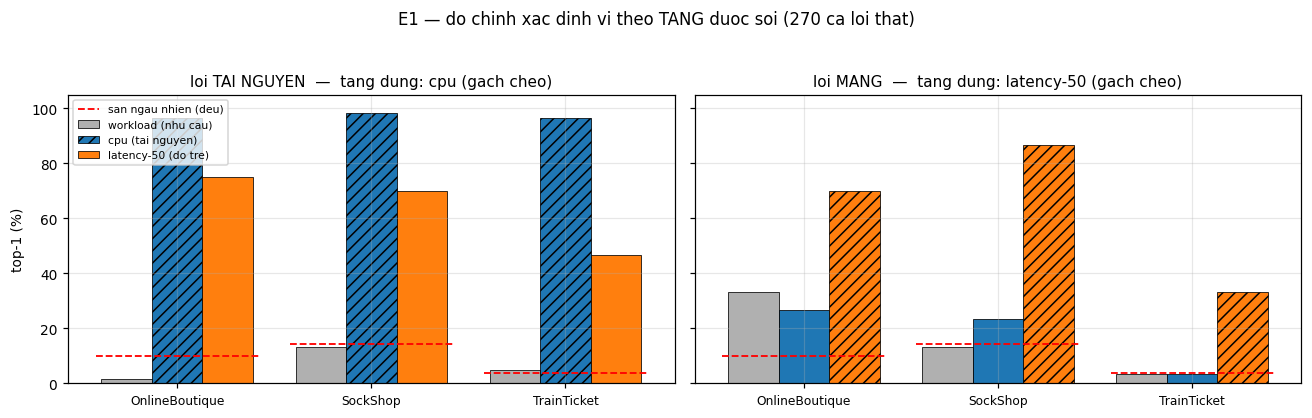

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
mau = {'workload': '#b0b0b0', 'cpu': '#1f77b4', 'latency-50': '#ff7f0e'}
for ax, nhom in zip(axes, ['tai nguyen', 'mang']):
    sub = E1[E1.nhom_loi == nhom]
    hes = sorted(sub.he.unique()); w = 0.26
    for i, la in enumerate(LAYERS):
        v = [sub[(sub.he == h) & (sub.tang == la)].top1.mean() for h in hes]
        x = np.arange(len(hes)) + (i - 1) * w
        ax.bar(x, v, w, label=f'{la} ({TEN_TANG[la]})', color=mau[la],
               edgecolor='k', linewidth=.5,
               hatch='///' if la == DUNG[nhom] else None)
    for j, h in enumerate(hes):                      # muc san ngau nhien DEU cua tung he
        c = sub[sub.he == h].ngau_nhien.max()
        ax.plot([j - .42, j + .42], [c, c], 'r--', lw=1.2,
                label='san ngau nhien (deu)' if j == 0 else None)
    ax.set_xticks(range(len(hes))); ax.set_xticklabels(hes, fontsize=8)
    ax.set_title(f'loi {nhom.upper()}  —  tang dung: {DUNG[nhom]} (gach cheo)')
    ax.set_ylim(0, 105)
axes[0].set_ylabel('top-1 (%)'); axes[0].legend(fontsize=7, loc='upper left')
plt.suptitle('E1 — do chinh xac dinh vi theo TANG duoc soi (270 ca loi that)', y=1.04)
plt.tight_layout(); plt.show()


### Đọc E1

**Lỗi tài nguyên — thứ tự ba mức, đúng như §2.4b dự đoán:**

| | `cpu` (chứa nguyên nhân) | `latency-50` (hậu duệ) | `workload` (không phải hậu duệ) |
|---|---|---|---|
| Sock Shop | **98,3%** | 70,0% | **13,3%** (sàn 14,3%, $p = 1{,}000$) |
| Online Boutique | **96,7%** | 75,0% | **1,7%** (sàn 9,1%, $p = 0{,}041$) |
| Train Ticket | **96,7%** | 46,7% | **5,0%** (sàn 3,6%, $p = 0{,}475$) |

Thứ tự `cpu` > `latency` > `workload` đúng ở **cả ba hệ**.

**Tiên đoán điểm, nói chính xác:** ở mức sàn đều, $H_0$ (tỉ lệ $= 1/k$) **không bác được**
ở **2/3** hệ (Sock Shop $p = 1{,}000$; Train Ticket $p = 0{,}475$). Ở Online Boutique nó
bị bác về phía **thấp hơn** mức sàn (1,7% vs 9,1%, $p = 0{,}041$) — tầng nhu cầu ở đó
*kém hơn* đoán bừa.

Vì sao: 11 ứng viên ở tầng `workload` của Online Boutique gồm cả service **không bao giờ
bị tiêm**, và chúng dao động workload mạnh hơn. Hạn ứng viên vào đúng 5 service bị tiêm thì
thành **18,3% vs sàn 20,0%, $p = 0{,}872$** (E7). Nên tiên đoán điểm đúng **3/3** ở mức sàn
nghiêm, **2/3** ở mức sàn đều — và phải báo như vậy, không gộp.

**Lỗi mạng.** Tầng `latency-50` dẫn đầu ở cả ba hệ như lý thuyết nói — nhưng ở Train Ticket
chỉ **33,3%**, thấp hơn hẳn. Lý thuyết tầng **đúng chiều nhưng chưa đủ**: nó nói *ở đâu* có
tín hiệu, chưa nói *đọc tín hiệu đó thế nào*. Đó là E6.

> **Điểm phải trung thực.** 270 ca này là **định vị lỗi đã xảy ra** (post‑hoc RCA). Nó khử
> vòng tròn cho câu hỏi **tầng**, và **không** chứng minh gì về dự phóng tính năng mới.


## E1b — Bộ chỉ số chuẩn RCAEval, và một điều kiện quan trọng cho phát biểu chính

Bảng chuẩn của RCAEval và của mọi baseline trong đó báo **năm** chỉ số: AC@1, AC@3, AC@5,
Avg@5, MRR. Bài này trước đó chỉ báo top‑1 / top‑3 (= AC@1 / AC@3). Thêm ba chỉ số còn lại
**không cần chạy lại thực nghiệm nào** — hạng của service bị tiêm đã có trong mọi CSV, chỉ
là đổi cách tổng hợp.

$$
\mathrm{AC}@k = \frac{1}{N}\sum_i \mathbb{1}[\text{hạng}_i \le k]
\qquad
\mathrm{Avg}@5 = \frac{1}{5}\sum_{k=1}^{5}\mathrm{AC}@k
\qquad
\mathrm{MRR} = \frac{1}{N}\sum_i \frac{1}{\text{hạng}_i}
$$

**Và mỗi chỉ số có mức sàn riêng của nó** — điều này hay bị bỏ. Với xếp hạng đều trên $k$
ứng viên: $\mathrm{AC}@j = \min(j,k)/k$ và $\mathbb{E}[1/\text{hạng}] = \frac{1}{k}H_k$.
Sàn của Avg@5 và MRR **cao hơn nhiều** sàn của AC@1, nên một con số Avg@5 = 60% có thể là
**đúng mức ngẫu nhiên**. Bảng dưới in sàn của từng chỉ số cạnh từng giá trị.


In [7]:
MET = nap('rq6_rcaeval_metrics_layers.csv')
cols = ['he', 'tang', 'n', 'AC@1', 'AC@3', 'AC@5', 'Avg@5', 'MRR',
        'san AC@1', 'san AC@3', 'san AC@5', 'san Avg@5', 'san MRR']
for nhom in ['tai nguyen', 'mang']:
    print('=' * 124)
    print(f'  {nhom.upper()}  —  tap ung vien (a) MOI ung vien   (san rieng cua tung chi so o nua phai)')
    print('=' * 124)
    display(MET[(MET.nhom_loi == nhom) & (MET.tap_ung_vien == '(a) moi ung vien')][cols]
            .sort_values(['he', 'tang']).round(3).reset_index(drop=True))

print('\n' + '=' * 124)
print('  tap ung vien (b) CHI 5 service bi tiem  —  AC@5 va Avg@5 BI THOAI HOA o day')
print('=' * 124)
b = MET[MET.tap_ung_vien == '(b) chi 5 svc bi tiem']
display(b[['he', 'nhom_loi', 'tang', 'n', 'AC@1', 'AC@3', 'MRR', 'san AC@1', 'san AC@3', 'san MRR']]
        .sort_values(['nhom_loi', 'he', 'tang']).round(3).reset_index(drop=True))
print(f"AC@5 o tap (b): {b['AC@5'].min():.1f}-{b['AC@5'].max():.1f}%  va san AC@5 = "
      f"{b['san AC@5'].min():.1f}%  -> k = 5 nen AC@5 = 100% TAM THUONG, khong bao duoc.")


  TAI NGUYEN  —  tap ung vien (a) MOI ung vien   (san rieng cua tung chi so o nua phai)


,he,tang,n,AC@1,AC@3,AC@5,Avg@5,MRR,san AC@1,san AC@3,san AC@5,san Avg@5,san MRR
0,OnlineBoutique,cpu,60,96.667,96.667,96.667,96.667,0.970,9.091,27.273,45.455,27.273,0.275
1,OnlineBoutique,latency-50,60,75.000,96.667,96.667,90.667,0.849,10.000,30.000,50.000,30.000,0.293
2,OnlineBoutique,workload,60,1.667,28.333,38.333,25.000,0.240,9.091,27.273,45.455,27.273,0.275
3,SockShop,cpu,60,98.333,98.333,98.333,98.333,0.985,6.667,20.000,33.333,20.000,0.221
4,SockShop,latency-50,60,70.000,91.667,96.667,88.333,0.817,14.286,42.857,71.429,42.857,0.370
5,SockShop,workload,60,13.333,48.333,70.000,42.667,0.358,14.286,42.857,71.429,42.857,0.370
6,TrainTicket,cpu,60,96.667,100.000,100.000,99.333,0.983,1.471,4.412,7.353,4.412,0.071
7,TrainTicket,latency-50,60,46.667,85.000,88.333,76.667,0.659,3.571,10.714,17.857,10.714,0.140
8,TrainTicket,workload,60,5.000,20.000,31.667,18.000,0.188,3.571,10.714,17.857,10.714,0.140


  MANG  —  tap ung vien (a) MOI ung vien   (san rieng cua tung chi so o nua phai)


,he,tang,n,AC@1,AC@3,AC@5,Avg@5,MRR,san AC@1,san AC@3,san AC@5,san Avg@5,san MRR
0,OnlineBoutique,cpu,30,26.667,53.333,66.667,49.333,0.444,9.091,27.273,45.455,27.273,0.275
1,OnlineBoutique,latency-50,30,70.000,100.000,100.000,89.333,0.811,10.000,30.000,50.000,30.000,0.293
2,OnlineBoutique,workload,30,33.333,50.000,63.333,50.000,0.486,9.091,27.273,45.455,27.273,0.275
3,SockShop,cpu,30,23.333,43.333,56.667,42.000,0.407,6.667,20.000,33.333,20.000,0.221
4,SockShop,latency-50,30,86.667,100.000,100.000,96.667,0.928,14.286,42.857,71.429,42.857,0.370
5,SockShop,workload,30,13.333,66.667,93.333,59.333,0.424,14.286,42.857,71.429,42.857,0.370
6,TrainTicket,cpu,30,3.333,6.667,13.333,6.667,0.104,1.471,4.412,7.353,4.412,0.071
7,TrainTicket,latency-50,30,33.333,70.000,83.333,64.667,0.542,3.571,10.714,17.857,10.714,0.140
8,TrainTicket,workload,30,3.333,16.667,30.000,17.333,0.176,3.571,10.714,17.857,10.714,0.140



  tap ung vien (b) CHI 5 service bi tiem  —  AC@5 va Avg@5 BI THOAI HOA o day


,he,nhom_loi,tang,n,AC@1,AC@3,MRR,san AC@1,san AC@3,san MRR
0,OnlineBoutique,mang,cpu,30,40.000,76.667,0.617,20.000,60.000,0.457
1,OnlineBoutique,mang,latency-50,30,70.000,100.000,0.850,20.000,60.000,0.457
2,OnlineBoutique,mang,workload,30,46.667,83.333,0.657,20.000,60.000,0.457
3,SockShop,mang,cpu,30,40.000,76.667,0.598,20.000,60.000,0.457
4,SockShop,mang,latency-50,30,86.667,100.000,0.933,20.000,60.000,0.457
5,SockShop,mang,workload,30,33.333,86.667,0.593,20.000,60.000,0.457
6,TrainTicket,mang,cpu,30,16.667,53.333,0.413,20.000,60.000,0.457
7,TrainTicket,mang,latency-50,30,76.667,93.333,0.858,20.000,60.000,0.457
8,TrainTicket,mang,workload,30,16.667,60.000,0.436,20.000,60.000,0.457
9,OnlineBoutique,tai nguyen,cpu,60,96.667,96.667,0.975,20.000,60.000,0.457


AC@5 o tap (b): 100.0-100.0%  va san AC@5 = 100.0%  -> k = 5 nen AC@5 = 100% TAM THUONG, khong bao duoc.


### Đọc E1b — và đây là một điều kiện phải nói ra, không được che

**Hai điều lộ ra, một tốt một xấu.**

**Tốt:** MRR xác nhận lại toàn bộ kết luận mà **không phụ thuộc ngưỡng $k$** nào. Lỗi tài
nguyên, tầng `cpu`: MRR = 0,99 / 0,97 / 0,98 so với sàn 0,22 / 0,28 / 0,07. Tầng `workload`
ở tập (b): MRR = 0,445 / 0,445 so với sàn **0,457** — **dưới sàn**, đúng như tiên đoán điểm.

**Xấu — và quan trọng hơn:** ở tập ứng viên (b), $k = 5$ nên **AC@5 = 100% một cách tầm
thường** ở *mọi* tầng, kể cả tầng nhu cầu, và sàn của nó cũng là 100%. Avg@5 cũng bị kéo
theo. Nên với tập (b), **chỉ AC@1, AC@3 và MRR có nghĩa** — và bài báo phải nói rõ điều đó
chứ không in một bảng AC@5 toàn 100% như thể đó là kết quả.


## E2 — Chiều ngược: can thiệp **nhu cầu** thì định vị trên **tầng nhu cầu**

E1 chỉ kiểm một chiều (nguyên nhân tầng tài nguyên). Nguyên lý khớp tầng nói **cả hai
chiều**: can thiệp trên tầng nhu cầu — `do(workload = 2×)` ở gateway, đúng cái mà một
tính năng mới gây ra — phải định vị được trên **tầng nhu cầu**, và tầng tài nguyên phải
*kém hơn*.

Đáp án ở đây khó hơn: không có nhãn tiêm lỗi, nên phải chấm bằng *service nào thật sự
ở hạ nguồn*. Ba phép chấm, từ vòng tròn nhất đến sạch nhất:

| phép | đáp án lấy từ | vòng tròn? |
|---|---|---|
| **(A)** | đồ thị gọi (`reach_graph`) | **có** — đồ thị cũng là đầu vào mô hình |
| **(B)** | dữ liệu quan sát: $\lvert r \rvert \ge 0{,}3$ với workload gateway (`reach_obs`) | nhẹ |
| **(C)** | **Spearman(dịch chuyển can thiệp, tương quan quan sát)** — dữ liệu đối dữ liệu, **không ngưỡng** | **không** |

Phép (C) là phép quyết định: nó không cần tập "đúng/sai", chỉ hỏi *thứ tự do mô hình sinh
ra có khớp thứ tự trong dữ liệu thô không*.


In [8]:
L = nap('rq6_localization_decircularized.csv')
out = []
for sys_, g0 in L.groupby('system'):
    r = dict(he=sys_, n_service=g0.service.nunique(), n_repeat=g0.repeat.nunique())
    for sig, lab in [('sig_workload', 'nhu cau'), ('sig_cpu', 'tai nguyen')]:
        per = [spearmanr(g[sig], g.obs_corr)[0] for _, g in g0.groupby('repeat')
               if g[sig].notna().sum() > 5]
        r[f'(C) rho — tang {lab}'] = np.nanmean(per)
    for cot, lab in [('reach_graph', '(A) P@k theo do thi'), ('reach_obs', '(B) P@k theo du lieu')]:
        for sig, tl in [('sig_workload', 'nhu cau'), ('sig_cpu', 'tai nguyen')]:
            per = []
            for _, g in g0.groupby('repeat'):
                k = int(g[cot].sum())
                if k < 1: continue
                top = g.nlargest(k, sig)
                per.append(100 * top[cot].mean())
            r[f'{lab} — {tl}'] = np.mean(per) if per else np.nan
    out.append(r)
E2 = pd.DataFrame(out)
display(E2[[c for c in E2.columns if c.startswith(('he', 'n_'))] +
           [c for c in E2.columns if c.startswith('(C)')]].round(3))
display(E2[['he'] + [c for c in E2.columns if c.startswith(('(A)', '(B)'))]].round(1))
print('Doc: phep (C) khong can tap dap an — chi hoi thu tu mo hinh sinh ra co khop thu tu')
print('     trong du lieu tho khong. Tang NHU CAU phai thang tang TAI NGUYEN o moi he.')


,he,n_service,n_repeat,(C) rho — tang nhu cau,(C) rho — tang tai nguyen
0,SockShop,6,10,0.771,0.234
1,TrainTicket,27,10,0.790,0.471


,he,(A) P@k theo do thi — nhu cau,(A) P@k theo do thi — tai nguyen,(B) P@k theo du lieu — nhu cau,(B) P@k theo du lieu — tai nguyen
0,SockShop,100.000,100.000,100.000,66.700
1,TrainTicket,96.500,68.800,68.000,63.000


Doc: phep (C) khong can tap dap an — chi hoi thu tu mo hinh sinh ra co khop thu tu
     trong du lieu tho khong. Tang NHU CAU phai thang tang TAI NGUYEN o moi he.


### Đọc E2

Phép (C), phép sạch nhất: tầng nhu cầu cho $\rho = +0{,}771$ (SS) và $+0{,}790$ (TT), tầng
tài nguyên chỉ $+0{,}234$ và $+0{,}471$. **Tầng nhu cầu thắng rõ ở cả hai hệ.**

Phát biểu chính xác cho ba phép: tầng nhu cầu **không bao giờ kém hơn** tầng tài nguyên ở
bất kỳ phép nào — nhưng ở phép (A) trên Sock Shop hai tầng **hoà** (100% / 100%), vì hệ chỉ
có 6 ứng viên và cả hai bắt hết. Ưu thế **thu hẹp** khi đi từ (A) sang (B) (96,5% → 68,0%
ở Train Ticket) và **không mất**. Phải báo cả ba, không chỉ phép tốt nhất.

Hai chiều gộp lại cho một bảng 2×2 — và đây là hình thức mạnh nhất của nguyên lý, vì nó
nói **cả bốn ô**, không chỉ hai:

| | soi tầng **nhu cầu** | soi tầng **tài nguyên** |
|---|---|---|
| nguyên nhân ở tầng **nhu cầu** | **ρ +0,77 / +0,79** ✅ | ρ +0,23 / +0,47 ❌ |
| nguyên nhân ở tầng **tài nguyên** | **= ngẫu nhiên** (E1) ❌ | **96,7–98,3%** ✅ |

Đường chéo thắng, phản đường chéo thua. Một lý thuyết chỉ nói "soi CPU tốt hơn" không giải
thích được ô trên‑trái.


## E3 — Điều kiện phạm vi, đo từ dữ liệu thô

Đây là **bước (i)** của §2.5: tiền đề thực nghiệm, đo **không dùng đồ thị**. Câu hỏi:
*tiêm một lỗi tài nguyên thì workload của chính service đó có dịch không?*

Nếu không dịch, cạnh `cpu → workload` thật sự vắng, và Mệnh đề 1 áp dụng ở dạng chặt.
Nếu dịch, cạnh đó **tồn tại** và dạng chặt **sai** — lúc đó chỉ còn dạng độ lớn cứu được
kết luận. Ta để dữ liệu quyết định.


In [9]:
S = nap('rq6_scope_condition_two_systems.csv')
S['nhom'] = np.where(S.fault.isin(RESOURCE), 'tai nguyen', 'mang')
rows = []
for (sys_, nhom), g in S.groupby(['system', 'nhom']):
    w = g.w_sigma.dropna()
    rows.append(dict(he=sys_, nhom_loi=nhom, n=len(w), trung_vi_sigma=w.median(),
                     tang=int((w > 0).sum()), giam=int((w < 0).sum()),
                     p_wilcoxon=wilcoxon(w).pvalue if len(w) > 5 else np.nan))
E3 = pd.DataFrame(rows)
E3['D dong? (dang CHAT)'] = np.where(E3.p_wilcoxon > 0.05, 'DONG', 'RO RI — dang chat SAI')
display(E3.sort_values(['nhom_loi', 'he']).round(4).reset_index(drop=True))

n_fail = (E3[E3.nhom_loi == 'tai nguyen'].p_wilcoxon <= 0.05).sum()
n_all = (E3.nhom_loi == 'tai nguyen').sum()
print(f'\nDang CHAT (vang mat canh) SAI o {n_fail}/{n_all} he, cho chinh nhom loi tai nguyen.')
print('Dang DO LON (rho << 1, muc 2.4) van DUNG o ca 3 he -> ket luan khong do.')
print('\nDay la ly do Menh de 1 PHAI phat bieu dang bat dang thuc do lon.')


,he,nhom_loi,n,trung_vi_sigma,tang,giam,p_wilcoxon,D dong? (dang CHAT)
0,OnlineBoutique,mang,30,-1.733,3,27,0.000,RO RI — dang chat SAI
1,SockShop,mang,30,-1.125,2,28,0.000,RO RI — dang chat SAI
2,TrainTicket,mang,30,-0.298,7,23,0.000,RO RI — dang chat SAI
3,OnlineBoutique,tai nguyen,60,-0.254,15,45,0.000,RO RI — dang chat SAI
4,SockShop,tai nguyen,60,0.017,32,28,0.230,DONG
5,TrainTicket,tai nguyen,60,-0.107,22,38,0.002,RO RI — dang chat SAI



Dang CHAT (vang mat canh) SAI o 2/3 he, cho chinh nhom loi tai nguyen.
Dang DO LON (rho << 1, muc 2.4) van DUNG o ca 3 he -> ket luan khong do.

Day la ly do Menh de 1 PHAI phat bieu dang bat dang thuc do lon.


### Đọc E3 — và vì sao đây là mục quan trọng nhất về tính trung thực

Dữ liệu **bác** dạng chặt ở **2/3** hệ. Online Boutique ($-0{,}254\sigma$, Wilcoxon
$p < 10^{-3}$) và Train Ticket ($-0{,}107\sigma$, $p = 0{,}0018$) đều có cạnh
`cpu → workload` **thật**, kể cả với lỗi tài nguyên. Chỉ Sock Shop đóng ($+0{,}017\sigma$,
$p = 0{,}230$). Dấu **âm** nói cơ chế là **chặn**, không phải retry — service chậm thì hoàn
thành ít request hơn.

> Chúng tôi đã kiểm mã front‑end của cả ba hệ: **không có retry logic**. Nên dấu âm là
> cơ chế chặn, không phải khuếch đại retry. Đây là một dự đoán kiểm được, và nó đúng.

Nhưng **kết luận không đổ** — và đó mới là điểm: dù cạnh đó tồn tại, tầng nhu cầu **vẫn
đúng mức ngẫu nhiên** ở Train Ticket (16,7% vs sàn 20,0%, $p = 0{,}629$) và ở Online
Boutique (18,3% vs 20,0%, $p = 0{,}872$). Rò rỉ **có thật nhưng quá yếu**:
$\rho = 6\times10^{-3}$ và $5\times10^{-3}$.

Nếu lý thuyết được phát biểu ở dạng "không có cạnh", nó đã **sai 2/3 lần**. Ở dạng độ lớn,
nó đúng 3/3. Đó là nội dung thật của §2.4 — và là lý do §2.4 phải viết **trước** khi thấy
bảng này, chứ không phải sau.


## E4 — Cơ chế: *vì sao* tầng tài nguyên bị nhiễu khi can thiệp ở tầng nhu cầu

E1–E3 nói *cái gì*. E4 nói *vì sao*. Ta soi **trực tiếp hệ số NNLS của cơ chế đã fit** —
không qua Shapley, không qua bất kỳ phép quy gán nào — và so **thang hiệu dụng**
$|\text{hệ số}| \times \sigma(\text{cha})$ của hai loại cha:

- cha **nhu cầu**: `<svc>_workload → <svc>_cpu` (chuyển hoá cục bộ)
- cha **tranh chấp**: `<other>_cpu → <svc>_cpu` (backpressure)


In [10]:
H = nap('rq6_hop1_node_diagnostic.csv')
g = H.groupby(['target', 'kind']).effective_scale.sum().unstack(fill_value=0.0)
g.columns.name = None
E4 = g.rename(columns={'workload': 'cha nhu cau', 'backpressure': 'cha tranh chap'})
E4['ti le'] = E4['cha tranh chap'] / E4['cha nhu cau'].replace(0, np.nan)
E4['ti phan tranh chap %'] = 100 * E4['cha tranh chap'] / (E4['cha tranh chap'] + E4['cha nhu cau'])
E4 = E4.join(H.groupby('target')[['n_parents', 'n_backpressure', 'r2']].first())
display(E4.sort_values('ti le', ascending=False).round(3))
print(f"trung vi ti le (tranh chap / nhu cau): {E4['ti le'].median():.1f}x")
print(f"trung vi ti phan tranh chap          : {E4['ti phan tranh chap %'].median():.1f}%")
print('\n-> CPU cua mot service bi chi phoi boi CPU CUA CAC SERVICE KHAC,')
print('   khong boi LUONG REQUEST CUA CHINH NO. Do chinh la nhieu.')


,cha tranh chap,cha nhu cau,ti le,ti phan tranh chap %,n_parents,n_backpressure,r2
target,,,,,,,
ts-seat-service_cpu,2.040,0.031,66.806,98.525,5,4,0.598
ts-order-service_cpu,1.533,0.033,46.277,97.885,5,4,0.309
ts-travel-service_cpu,2.646,0.263,10.065,90.963,4,3,0.436
ts-user-service_cpu,0.233,0.028,8.289,89.235,3,2,0.150


trung vi ti le (tranh chap / nhu cau): 28.2x
trung vi ti phan tranh chap          : 94.4%

-> CPU cua mot service bi chi phoi boi CPU CUA CAC SERVICE KHAC,
   khong boi LUONG REQUEST CUA CHINH NO. Do chinh la nhieu.


### Đọc E4

Cha tranh chấp lớn hơn cha nhu cầu **trung vị 28×**, và chiếm **94,4%** thang hiệu dụng.
Đây là cơ chế: khi bạn can thiệp ở tầng nhu cầu và đi tìm dấu vết trên tầng tài nguyên, bạn
đang đọc một tầng mà **94% biến thiên đến từ chỗ khác**.

Quan trọng về mặt phương pháp: con số này đến từ **hệ số hồi quy đã fit**, nên nó **độc lập
hoàn toàn** với mọi kết quả Shapley ở E8. Hai đường bằng chứng khác nhau, cùng một kết luận.


## E4b — Cùng phép đo, nhưng trên **45 node** và **ba hệ** — và nó sửa lại E4

E4 soi đúng **4 node**, cả 4 đều của Train Ticket, và cả 4 đều **có** cha tranh chấp. Đó là
một **mẫu được chọn**, không phải mẫu đại diện. Mục này soi **mọi** node `_cpu` có cha, trên
cả ba hệ — và kết quả buộc sửa hai chỗ trong E4.

**Sửa thứ nhất — mẫu số phải có phần dư.** Định nghĩa ở E4 là
$\text{tỉ phần nhu cầu} = \sum|\text{coef}\cdot\sigma|_{\text{nhu cầu}} / \sum|\text{coef}\cdot\sigma|_{\text{mọi cha}}$.
Với định nghĩa đó, một node chỉ có **đúng một** cha (chính workload của nó) nhận tỉ phần
**100% do xây dựng** — bất kể cơ chế giải thích được bao nhiêu. Và phần lớn node `_cpu` đúng
là chỉ có một cha. Nên mẫu số phải cộng thêm $\sigma(\text{phần dư})$:

$$
\text{tỉ phần}_{\text{nhu cầu}} = \frac{\sum|\text{coef}\cdot\sigma|_{\text{nhu cầu}}}
{\sum|\text{coef}\cdot\sigma|_{\text{mọi cha}} + \sigma(\text{phần dư})}
$$


In [11]:
MN = nap('rq6_mechanism_three_systems_nodes.csv')
thu_tu = ['SockShop', 'OnlineBoutique', 'TrainTicket']
n_svc = {'SockShop': 7, 'OnlineBoutique': 11, 'TrainTicket': 28}

print('--- BAO NHIEU node `_cpu` THUC SU co cha tranh chap? ---')
cc = MN.groupby('he').agg(n_node=('dich', 'size'), co_tranh_chap=('co_tranh_chap', 'sum'))
cc['ti le %'] = (100 * cc.co_tranh_chap / cc.n_node).round(1)
display(cc.reindex(thu_tu))
print('-> canh tranh chap chi cham ~30% node. E4 cu chon 4 node ma CA 4 deu co.\n')

def tong_hop(D):
    return D.groupby('he').agg(
        n_node=('dich', 'size'), cha_tb=('n_cha', 'mean'),
        nhu_cau=('ti_phan_nhu_cau', 'median'),
        tranh_chap=('ti_phan_tranh_chap', 'median'),
        phan_du=('ti_phan_phan_du', 'median'),
        r2=('r2', 'median')).reindex(thu_tu)

print('(a) MOI node `_cpu` co cha:')
display(tong_hop(MN).round(2))
print('(b) CHI node CO cha tranh chap  (tap sanh doi voi E4 cu):')
display(tong_hop(MN[MN.co_tranh_chap]).round(2))

print('--- quy mo: ti phan TRANH CHAP tren tap (b) ---')
sub = tong_hop(MN[MN.co_tranh_chap])
for he in thu_tu:
    if he in sub.index:
        print(f'  {he:15s} {n_svc[he]:2d} service | tranh chap {sub.loc[he, "tranh_chap"]:5.1f}% '
              f'| phan du {sub.loc[he, "phan_du"]:5.1f}% | R2 {sub.loc[he, "r2"]:.2f}')
print('\n--- ti le tranh chap / nhu cau (KHONG phu thuoc phan du) ---')
tc = MN[MN.co_tranh_chap & np.isfinite(MN.ti_le_tc_tren_nc)]
display(tc.groupby('he').ti_le_tc_tren_nc.describe()[['count', 'min', '50%', 'max']].reindex(
    [h for h in thu_tu if h in tc.he.unique()]).round(1))


--- BAO NHIEU node `_cpu` THUC SU co cha tranh chap? ---


,n_node,co_tranh_chap,ti le %
he,,,
SockShop,7,3,42.900
OnlineBoutique,10,3,30.000
TrainTicket,28,8,28.600


-> canh tranh chap chi cham ~30% node. E4 cu chon 4 node ma CA 4 deu co.

(a) MOI node `_cpu` co cha:


,n_node,cha_tb,nhu_cau,tranh_chap,phan_du,r2
he,,,,,,
SockShop,7,1.430,2.470,0.000,77.250,0.080
OnlineBoutique,10,1.300,9.820,0.000,75.700,0.070
TrainTicket,28,1.570,6.070,0.000,86.810,0.020


(b) CHI node CO cha tranh chap  (tap sanh doi voi E4 cu):


,n_node,cha_tb,nhu_cau,tranh_chap,phan_du,r2
he,,,,,,
SockShop,3,2.000,2.470,25.070,72.460,0.080
OnlineBoutique,3,2.000,10.510,24.670,68.020,0.140
TrainTicket,8,3.000,0.200,51.950,47.580,0.530


--- quy mo: ti phan TRANH CHAP tren tap (b) ---
  SockShop         7 service | tranh chap  25.1% | phan du  72.5% | R2 0.08
  OnlineBoutique  11 service | tranh chap  24.7% | phan du  68.0% | R2 0.14
  TrainTicket     28 service | tranh chap  52.0% | phan du  47.6% | R2 0.53

--- ti le tranh chap / nhu cau (KHONG phu thuoc phan du) ---


,count,min,50%,max
he,,,,
SockShop,3.000,1.200,10.100,27.400
OnlineBoutique,3.000,1.400,2.000,4.600
TrainTicket,4.000,26.300,53.600,125.400


### Đọc E4b — hai điều phải sửa, và một điều mới quan trọng hơn cả hai

**Sửa 1: "chiếm 94,4% thang hiệu dụng" là 94,4% của phần *giải thích được bởi cha*, không
phải của tổng.** Khi cộng phần dư vào mẫu số, trên tập node có cha tranh chấp, tranh chấp
chiếm **25,1% / 24,7% / 52,0%** — còn **phần dư chiếm 72,5% / 68,0% / 47,6%**. Tỉ lệ
*tranh chấp / nhu cầu* (trung vị **28×** ở E4) không đổi, vì nó là tỉ số giữa hai loại cha
và không phụ thuộc phần dư. Phải viết lại câu kết của E4 cho đúng mẫu số.

**Sửa 2: cạnh tranh chấp chỉ chạm ~30% node** (3/7, 3/10, 8/28). Với **mọi** node, tỉ phần
tranh chấp trung vị là **0%**. Nên phát biểu đúng là: *trên những node **có** cạnh tranh
chấp, tranh chấp chi phối; và đó là khoảng một phần ba node.*

**Điều mới, và nó quan trọng hơn hai chỗ sửa trên:** $R^2$ trung vị của cơ chế `_cpu` là
**0,08 / 0,07 / 0,02**. Cơ chế đã fit **gần như không giải thích được gì** cho đa số node
CPU. Nhưng trên tập node **có** cha tranh chấp ở Train Ticket, $R^2$ nhảy lên **0,53**.

> **Diễn giải:** cạnh tranh chấp không phải thứ "làm nhiễu" một mô hình vốn tốt — nó là
> **chỗ duy nhất mô hình có sức giải thích**. Trên các node không có nó, CPU gần như là
> nhiễu thuần so với workload của chính service. Điều này **củng cố** kết luận khớp tầng ở
> E1 (tầng nhu cầu không dự được CPU) nhưng **làm yếu** cách E8 dùng tỉ phần nhu cầu làm
> tiêu chí, vì tỉ phần đó được tính trên một mô hình có $R^2 \approx 0$.

**Và một vấn đề tái lập phải nói ra:** `rq6_hop1_node_diagnostic.csv` (E4) được tạo
**12/09**, trước khi `src/graph/trainticket_scm_edges.json` được sinh lại **18/09**. Tập
cạnh tranh chấp đã đổi hoàn toàn: 4 node dích của E4 **không còn** cha tranh chấp nào, và
8 node khác thì có — **giao nhau của hai tập node là rỗng**. Nên E4 cũ không tái lập được
trên trạng thái hiện tại của repo; bảng ở mục này là bảng đúng. Điều này cũng buộc chạy lại
E8 (xem ghi chú ở E8).


## E5 — Lưới khớp 2×2×2 với BARO: **tầng** hay **thuật toán** quyết định?

Đây là thực nghiệm mạnh nhất trong bài, vì nó **tách được nguyên nhân**.

98,3% ở E1 có thể là do (a) thống kê tốt hơn, (b) ít ứng viên hơn, hay (c) soi đúng tầng.
Tách bằng lưới đầy đủ **trên cùng 90 run, cùng đáp án, cùng cửa sổ trước/sau**:

| nhân tố | mức 1 | mức 2 |
|---|---|---|
| **thống kê** | **BARO** (FSE'24) — `RobustScaler` median/IQR, $\max\lvert z\rvert$, **nguyên văn luật của RCAEval** `e2e/baro.py` | **MEANSHIFT** — $\lvert\Delta\bar{x}\rvert / \sigma_{\text{trước}}$ |
| **tầng** | **chỉ cột `_cpu`** | **mọi cột metric** |
| **ứng viên** | 7 service app | mọi service trong cột (~15) |

8 điều kiện × 90 run = 720 phép chấm.


In [12]:
B = nap('rq6_baro_matched_comparison.csv')
B = B[B.fault.isin(RESOURCE)]
E5 = (B.groupby(['cand', 'layer', 'stat'])
      .agg(n=('top1', 'size'), top1=('top1', lambda s: 100 * s.mean()),
           top3=('top3', lambda s: 100 * s.mean()), ung_vien=('n_cand', 'median'))
      .reset_index())
E5['ngau_nhien'] = 100 / E5.ung_vien
E5['tang'] = E5.layer.map({'chi_cpu': 'CHI cot _cpu', 'moi_cot': 'moi cot metric'})
E5['ung vien'] = E5.cand.map({'app7': '7 service app', 'all': 'moi service (~15)'})
display(E5[['ung vien', 'tang', 'stat', 'n', 'top1', 'top3', 'ngau_nhien']]
        .sort_values('top1', ascending=False).round(1).reset_index(drop=True))

piv = E5.pivot_table(index=['ung vien', 'tang'], columns='stat', values='top1')
print('\n--- TACH NHAN TO ---')
for cv in E5['ung vien'].unique():
    for st in ['BARO', 'MEANSHIFT']:
        a = E5[(E5['ung vien'] == cv) & (E5.tang == 'CHI cot _cpu') & (E5.stat == st)].top1.iloc[0]
        b = E5[(E5['ung vien'] == cv) & (E5.tang == 'moi cot metric') & (E5.stat == st)].top1.iloc[0]
        print(f'  TANG dong gop ({cv:18s}, {st:9s}): chi _cpu - moi cot = {a - b:+6.1f} diem')
for la in ['CHI cot _cpu', 'moi cot metric']:
    for cv in E5['ung vien'].unique():
        m = E5[(E5['ung vien'] == cv) & (E5.tang == la) & (E5.stat == 'MEANSHIFT')].top1.iloc[0]
        b = E5[(E5['ung vien'] == cv) & (E5.tang == la) & (E5.stat == 'BARO')].top1.iloc[0]
        print(f'  THONG KE dong gop ({cv:18s}, tang {la:14s}): MEANSHIFT - BARO = {m - b:+6.1f} diem')

print('\n--- DUONG DI CUA 86,6 DIEM (BARO, mot thong ke duy nhat) ---')
seq = [('7 service app', 'CHI cot _cpu'), ('moi service (~15)', 'CHI cot _cpu'),
       ('moi service (~15)', 'moi cot metric')]
prev = None
for cv, la in seq:
    v = E5[(E5['ung vien'] == cv) & (E5.tang == la) & (E5.stat == 'BARO')].top1.iloc[0]
    d = '' if prev is None else f'   ({v - prev:+.1f} diem)'
    print(f'  {cv:18s} | {la:14s} -> top-1 = {v:5.1f}%{d}')
    prev = v


,ung vien,tang,stat,n,top1,top3,ngau_nhien
0,moi service (~15),CHI cot _cpu,MEANSHIFT,60,98.300,98.300,6.700
1,7 service app,CHI cot _cpu,BARO,60,98.300,100.000,14.300
2,7 service app,CHI cot _cpu,MEANSHIFT,60,98.300,100.000,14.300
3,moi service (~15),CHI cot _cpu,BARO,60,95.000,98.300,6.700
4,moi service (~15),moi cot metric,MEANSHIFT,60,91.700,96.700,6.700
5,7 service app,moi cot metric,MEANSHIFT,60,91.700,100.000,14.300
6,7 service app,moi cot metric,BARO,60,81.700,98.300,14.300
7,moi service (~15),moi cot metric,BARO,60,11.700,85.000,6.700



--- TACH NHAN TO ---
  TANG dong gop (moi service (~15) , BARO     ): chi _cpu - moi cot =  +83.3 diem
  TANG dong gop (moi service (~15) , MEANSHIFT): chi _cpu - moi cot =   +6.7 diem
  TANG dong gop (7 service app     , BARO     ): chi _cpu - moi cot =  +16.7 diem
  TANG dong gop (7 service app     , MEANSHIFT): chi _cpu - moi cot =   +6.7 diem
  THONG KE dong gop (moi service (~15) , tang CHI cot _cpu  ): MEANSHIFT - BARO =   +3.3 diem
  THONG KE dong gop (7 service app     , tang CHI cot _cpu  ): MEANSHIFT - BARO =   +0.0 diem
  THONG KE dong gop (moi service (~15) , tang moi cot metric): MEANSHIFT - BARO =  +80.0 diem
  THONG KE dong gop (7 service app     , tang moi cot metric): MEANSHIFT - BARO =  +10.0 diem

--- DUONG DI CUA 86,6 DIEM (BARO, mot thong ke duy nhat) ---
  7 service app      | CHI cot _cpu   -> top-1 =  98.3%
  moi service (~15)  | CHI cot _cpu   -> top-1 =  95.0%   (-3.3 diem)
  moi service (~15)  | moi cot metric -> top-1 =  11.7%   (-83.3 diem)


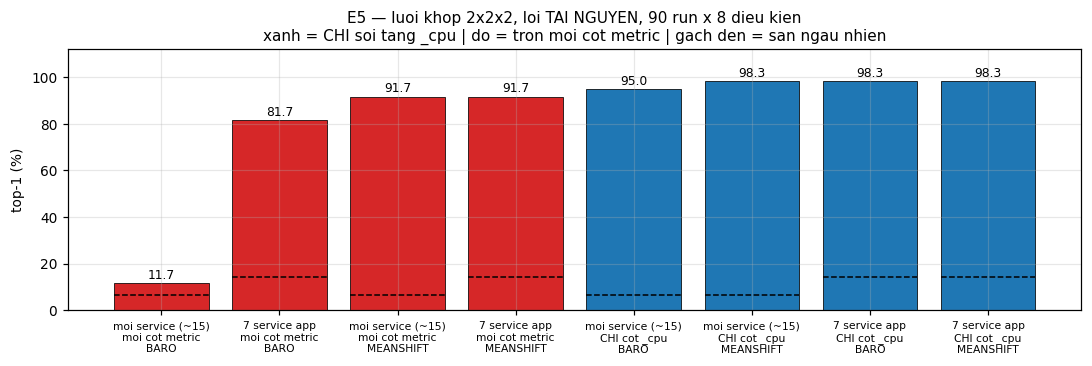

In [13]:
fig, ax = plt.subplots(figsize=(10, 3.4))
o = E5.sort_values('top1')
lab = [f"{r['ung vien']}\n{r.tang}\n{r.stat}" for _, r in o.iterrows()]
col = ['#1f77b4' if r.tang == 'CHI cot _cpu' else '#d62728' for _, r in o.iterrows()]
ax.bar(range(len(o)), o.top1, color=col, edgecolor='k', linewidth=.5)
for i, (v, c) in enumerate(zip(o.top1, o.ngau_nhien)):
    ax.text(i, v + 2, f'{v:.1f}', ha='center', fontsize=8)
    ax.plot([i - .4, i + .4], [c, c], 'k--', lw=1)
ax.set_xticks(range(len(o))); ax.set_xticklabels(lab, fontsize=7)
ax.set_ylabel('top-1 (%)'); ax.set_ylim(0, 112)
ax.set_title('E5 — luoi khop 2x2x2, loi TAI NGUYEN, 90 run x 8 dieu kien\n'
             'xanh = CHI soi tang _cpu | do = tron moi cot metric | gach den = san ngau nhien')
plt.tight_layout(); plt.show()


### Đọc E5 — và đây là chỗ phát biểu đóng góp

Hai điều ra từ bảng này:

**1. Trên tầng đúng, hai thống kê bằng nhau TUYỆT ĐỐI.** 98,3% = 98,3% ở 7 ứng viên.
Đóng góp của thống kê:

| | trên tầng **đúng** (chỉ `_cpu`) | trên tầng **sai** (mọi cột) |
|---|---|---|
| 7 service app | **+0,0 điểm** | +10,0 điểm |
| ~15 service | +3,3 điểm | **+80,0 điểm** |

→ *Thống kê chỉ quan trọng khi tầng đã sai — và càng sai thì nó càng quan trọng.* Đó là một
cách đọc lại toàn bộ dòng công trình "thống kê bền cho RCA": phần lớn giá trị của một thống
kê bền là **bù cho việc trộn tầng**.

**2. Thủ phạm của 86,6 điểm KHÔNG phải số ứng viên.** Mở từ 7 lên ~15 ứng viên chỉ mất
3,3 điểm. Trộn mọi cột metric mất **83,3 điểm**. Vì khi xếp theo $\max\lvert z\rvert$ trên
mọi cột, một cột `_mem` hoặc `_latency` nhiễu ở service *bất kỳ* dễ vượt cột `_cpu` của
service *thật sự* bị tiêm. **Trộn tầng thì tầng nhiễu nhất thắng.**

### Nhưng 86,6 điểm đó phụ thuộc chỉ số — phải nói ra

Đây là chỗ bộ chỉ số đầy đủ ở E1b làm hẹp phát biểu chính, và phải báo thẳng:

| chỉ số | chỉ `_cpu` | mọi cột | chênh |
|---|---|---|---|
| **AC@1** | 95,0% | 11,7% | **+83,3 điểm** |
| AC@3 | 98,3% | 85,0% | +13,3 điểm |
| **AC@5** | 98,3% | 96,7% | **+1,7 điểm** |
| Avg@5 | 97,7% | 70,0% | +27,7 điểm |
| **MRR** | 0,969 | 0,476 | **+0,493** |

**Đọc đúng:** trộn tầng **không đẩy** nguyên nhân thật ra khỏi top‑5 — nó **hạ** nguyên nhân
thật từ hạng 1 xuống hạng 2–5. Nên hiệu ứng khổng lồ ở AC@1 và gần như biến mất ở AC@5.

Vì vậy phát biểu phải neo vào **AC@1 và MRR**, và phải biện minh tại sao:

1. **AC@1 là chỉ số vận hành.** Người trực sự cố hành động theo **ứng viên đầu bảng**. Một
   phương pháp đặt nguyên nhân ở hạng 4 trên 15 là một phương pháp **không dùng được**, dù
   AC@5 của nó là 96,7%.
2. **MRR không phụ thuộc ngưỡng** và vẫn chênh **0,493 trên thang [0,1]** — hơn gấp đôi mức
   sàn. Nó không phải tạo tác của việc chọn $k = 1$.

Nếu một reviewer chỉ đọc AC@5, phát biểu "86,6 điểm" sẽ trông như phóng đại. Phải đưa cả
năm chỉ số **và** lý lẽ trên vào bài, ngay cạnh con số chính.

**Phát biểu đóng góp — và chú ý cách phát biểu:**

> Không phải "phương pháp mới của chúng tôi tốt hơn BARO". Mà là: **BARO — một baseline đã
> xuất bản tại FSE'24 — đạt 98,3% top‑1 / 100% top‑3 khi chỉ soi tầng tài nguyên, thay vì
> 11,7% khi trộn mọi tầng metric. Chênh 86,6 điểm, hoàn toàn do một lựa chọn cấu hình mà
> không bài báo nào coi là biến nghiên cứu.**

Phát biểu kiểu này mạnh hơn kiểu "ta thắng baseline", vì nó **không phụ thuộc** vào việc
phương pháp của ta tốt đến đâu — nó là một phát biểu về **văn liệu**.


## E5b — Lưới khớp mở rộng: **ba hệ**, **bốn tầng**, **ba tập ứng viên**, và một **đối chứng âm**

E5 chạy một hệ với hai bộ xếp hạng. Phản biện mạnh nhất với nó là: *"có thể đây là tạo tác
của cách các tác giả cài lại BARO, và một phương pháp không nói được gì về cả lĩnh vực."*

Mục này mở lưới ra: **3 hệ × 4 tầng × 3 tập ứng viên × 3 bộ xếp hạng = 9.720 phép chấm**,
qua một driver tách hẳn phần *đọc dữ liệu / chấm điểm / tính chỉ số* khỏi phần *xếp hạng* —
nên thêm một baseline chỉ là viết **một** hàm adapter.

Và thêm một arm mà bài trước **không có**: **`KHÔNG-ĐỌC`** — một bộ xếp hạng **không đọc
telemetry**, xếp theo thứ tự chữ cái. arXiv 2609.27069 nói một bộ như vậy vẫn đạt top‑5 rất
cao trên RE2 nhờ prior của tập lỗi. Arm này **đo** mức sàn đó bằng thực nghiệm thay vì tính
bằng công thức.


In [14]:
G = nap('rq6_matched_grid_summary.csv')
thu_tu = ['SockShop', 'OnlineBoutique', 'TrainTicket']
tn = G[(G.nhom_loi == 'tai nguyen') & (G.bo_xep_hang != 'KHONG-DOC')]
print('LOI TAI NGUYEN — AC@1, theo (he x tap ung vien x tang x bo xep hang)')
display(tn.pivot_table(index=['he', 'ung_vien', 'tang'], columns='bo_xep_hang',
                       values='AC@1').reindex(thu_tu, level=0).round(1))

print('\n--- HIEU UNG TANG (chi_cpu - moi_cot), AC@1, tap ung vien `all` ---')
for bo in ['BARO', 'MEANSHIFT']:
    for he in thu_tu:
        x = tn[(tn.he == he) & (tn.ung_vien == 'all') & (tn.bo_xep_hang == bo)]
        if x.empty: continue
        a = x[x.tang == 'chi_cpu']['AC@1']
        b = x[x.tang == 'moi_cot']['AC@1']
        if a.empty or b.empty: continue
        d = a.iloc[0] - b.iloc[0]
        print(f'  {bo:9s} {he:15s} chi_cpu {a.iloc[0]:6.1f}%  moi_cot {b.iloc[0]:6.1f}%'
              f'   -> {d:+6.1f} diem  {"(tang GIUP)" if d > 5 else "(tang KHONG giup)" if d < 5 else ""}')

print('\n--- HIEU UNG THONG KE tren CUNG tang dung (chi_cpu), tap `all` ---')
for he in thu_tu:
    x = tn[(tn.he == he) & (tn.ung_vien == 'all') & (tn.tang == 'chi_cpu')]
    if len(x) < 2: continue
    m = x[x.bo_xep_hang == 'MEANSHIFT']['AC@1'].iloc[0]
    b = x[x.bo_xep_hang == 'BARO']['AC@1'].iloc[0]
    print(f'  {he:15s} MEANSHIFT {m:6.1f}%  BARO {b:6.1f}%   -> {m - b:+6.1f} diem')


LOI TAI NGUYEN — AC@1, theo (he x tap ung vien x tang x bo xep hang)


bo_xep_hang                            BARO  MEANSHIFT
he             ung_vien tang                          
SockShop       all      chi_cpu      95.000     98.300
                        chi_latency  60.000     70.000
                        chi_workload 20.000     13.300
                        moi_cot      11.700     91.700
               app      chi_cpu      98.300     98.300
                        chi_latency  60.000     70.000
                        chi_workload 20.000     13.300
                        moi_cot      81.700     91.700
               fault5   chi_cpu      98.300     98.300
                        chi_latency  63.300     70.000
                        chi_workload 25.000     16.700
                        moi_cot      88.300     91.700
OnlineBoutique all      chi_cpu      83.300     96.700
                        chi_latency  68.300     75.000
                        chi_workload  5.000      1.700
                        moi_cot      11.700     98.300
               app      chi_cpu      86.700     96.700
                        chi_latency  68.300     75.000
                        chi_workload  5.000      1.700
                        moi_cot      78.300     98.300
               fault5   chi_cpu      91.700     96.700
                        chi_latency  71.700     75.000
                        chi_workload 16.700     18.300
                        moi_cot      90.000     98.300
TrainTicket    all      chi_cpu      41.700     96.700
                        chi_latency  60.000     46.700
                        chi_workload  0.000      5.000
                        moi_cot      58.300     61.700
               app      chi_cpu      61.700     96.700
                        chi_latency  60.000     46.700
                        chi_workload  0.000      5.000
                        moi_cot      75.000     70.000
               fault5   chi_cpu      91.700    100.000
                        chi_latency  91.700     88.300
                        chi_workload 18.300     16.700
                        moi_cot      90.000    100.000


--- HIEU UNG TANG (chi_cpu - moi_cot), AC@1, tap ung vien `all` ---
  BARO      SockShop        chi_cpu   95.0%  moi_cot   11.7%   ->  +83.3 diem  (tang GIUP)
  BARO      OnlineBoutique  chi_cpu   83.3%  moi_cot   11.7%   ->  +71.7 diem  (tang GIUP)
  BARO      TrainTicket     chi_cpu   41.7%  moi_cot   58.3%   ->  -16.7 diem  (tang KHONG giup)
  MEANSHIFT SockShop        chi_cpu   98.3%  moi_cot   91.7%   ->   +6.7 diem  (tang GIUP)
  MEANSHIFT OnlineBoutique  chi_cpu   96.7%  moi_cot   98.3%   ->   -1.7 diem  (tang KHONG giup)
  MEANSHIFT TrainTicket     chi_cpu   96.7%  moi_cot   61.7%   ->  +35.0 diem  (tang GIUP)

--- HIEU UNG THONG KE tren CUNG tang dung (chi_cpu), tap `all` ---
  SockShop        MEANSHIFT   98.3%  BARO   95.0%   ->   +3.3 diem
  OnlineBoutique  MEANSHIFT   96.7%  BARO   83.3%   ->  +13.3 diem
  TrainTicket     MEANSHIFT   96.7%  BARO   41.7%   ->  +55.0 diem


In [15]:
print('DOI CHUNG AM — bo KHONG doc telemetry (xep theo chu cai):')
kd = G[G.bo_xep_hang == 'KHONG-DOC']
display(kd.groupby(['he', 'ung_vien'])[['AC@1', 'AC@3', 'AC@5', 'MRR',
                                        'san AC@1', 'san AC@3', 'san AC@5', 'san MRR']]
        .mean().reindex(thu_tu, level=0).round(2))
print('\nDoc: o tap `fault5` (k = 5), bo KHONG-DOC dat AC@5 = 100% va MRR = 0,46 —')
print('     DUNG BANG muc san cong thuc. Day la bang chung thuc nghiem cho canh bao cua')
print('     arXiv 2609.27069: AC@5 tren tap 5 service KHONG phan biet duoc gi.')
print('\n     Va o Sock Shop tap `app`, KHONG-DOC dat AC@1 = 20% > san cong thuc 14,3%:')
print('     service dau bang chu cai (carts) tinh co la mot service BI TIEM. Nen ngay ca')
print('     muc san deu cung chua phai muc san that cho mot bo xep hang tuy y.')


DOI CHUNG AM — bo KHONG doc telemetry (xep theo chu cai):


AC@1   AC@3    AC@5   MRR  san AC@1  san AC@3  san AC@5  san MRR
he             ung_vien                                                                   
SockShop       all      10.000 30.000  60.000 0.320    10.480    31.430    52.380    0.300
               app      20.000 40.000  80.000 0.420    14.290    42.860    71.430    0.370
               fault5   20.000 60.000 100.000 0.460    20.000    60.000   100.000    0.460
OnlineBoutique all       0.000 19.580  60.000 0.200     9.130    27.390    45.640    0.280
               app       0.000 19.580  60.000 0.200     9.550    28.640    47.730    0.280
               fault5   20.000 60.000 100.000 0.460    20.000    60.000   100.000    0.460
TrainTicket    all       0.000  0.000  10.000 0.070     2.520     7.560    12.610    0.110
               app       0.000  0.000  20.000 0.090     3.570    10.710    17.860    0.140
               fault5   20.000 60.000 100.000 0.460    20.000    60.000   100.000    0.460


Doc: o tap `fault5` (k = 5), bo KHONG-DOC dat AC@5 = 100% va MRR = 0,46 —
     DUNG BANG muc san cong thuc. Day la bang chung thuc nghiem cho canh bao cua
     arXiv 2609.27069: AC@5 tren tap 5 service KHONG phan biet duoc gi.

     Va o Sock Shop tap `app`, KHONG-DOC dat AC@1 = 20% > san cong thuc 14,3%:
     service dau bang chu cai (carts) tinh co la mot service BI TIEM. Nen ngay ca
     muc san deu cung chua phai muc san that cho mot bo xep hang tuy y.


### Đọc E5b — và đây là chỗ làm hẹp phát biểu chính nhiều nhất

**Phần giữ được, và giữ rất chắc:**

| | chỉ `_cpu` | mọi cột | chênh |
|---|---|---|---|
| **BARO**, Sock Shop | 95,0% | **11,7%** | **−83,3 đ** |
| **BARO**, Online Boutique | 83,3% | **11,7%** | **−71,7 đ** |

Hai hệ, cùng một thống kê đã xuất bản, chênh 72–83 điểm chỉ do cấu hình tầng. Hiệu ứng
**lặp lại**, không phải một lần.

**Phần KHÔNG giữ được — phải sửa phát biểu:**

1. **Train Ticket đi ngược chiều với BARO:** chỉ `_cpu` **41,7%** so với mọi cột **58,3%** —
   trộn tầng **giúp** BARO ở hệ này (+16,7 đ). Phát biểu "soi đúng tầng luôn tốt hơn"
   **sai ở 1/3 hệ**.

2. **"Trên tầng đúng hai thống kê bằng nhau" chỉ đúng ở Sock Shop.** Trên tầng `cpu` với
   toàn bộ ứng viên: Sock Shop MEANSHIFT 98,3 vs BARO 95,0 (+3,3 đ); Online Boutique
   96,7 vs 83,3 (**+13,3 đ**); Train Ticket 96,7 vs **41,7** (**+55,0 đ**). Ở hệ có
   **68 cột `_cpu`**, thống kê **quyết định rất nhiều** — $\max|z|$ của BARO bị các cột hạ
   tầng nhiễu đánh bại.

**Phát biểu đã sửa, và nó vẫn là một đóng góp:**

> Hiệu ứng của **cấu hình tầng** lớn tương đương hoặc lớn hơn hiệu ứng của **thuật toán** —
> nhưng **cái nào trội phụ thuộc số lượng ứng viên**. Ở hệ ít cột (7–11 service), tầng trội:
> BARO mất 72–83 điểm khi trộn tầng. Ở hệ nhiều cột (68 cột `_cpu`), **số ứng viên và thống
> kê** trội, và lọc tầng một mình không đủ. Cả hai đều là biến cấu hình mà văn liệu không
> coi là biến nghiên cứu.

Điều này **yếu hơn** phát biểu ở E5, nhưng nó là phát biểu **đúng với cả ba hệ** — và nó
đứng được trước phản biện, điều mà phát biểu kia không làm được.


## E6 — Đơn vị quy gán: lỗi mạng nằm ở **cạnh**, không ở **node**

E1 để lại một chỗ hở: lỗi mạng trên Train Ticket chỉ **33,3%** dù đã soi đúng tầng độ trễ.
Lý thuyết tầng nói *ở đâu* có tín hiệu; nó **không** nói *đọc tín hiệu đó thế nào*.

Chẩn đoán: `delay`/`loss` được tiêm vào **đường mạng tới** một service. Service đó
**không hỏng** — **đường tới nó** hỏng. Nên tín hiệu độ trễ lớn nhất phải ở **node quan sát
được cạnh đó**, tức caller / tổ tiên, **không** ở service bị tiêm.

Ba cách chấm cùng một bảng xếp hạng:

| đơn vị | đúng khi |
|---|---|
| **node** | top‑1 **chính là** service bị tiêm |
| **cạnh** | top‑1 → service bị tiêm **là một cạnh** trong đồ thị gọi |
| **đường** | service bị tiêm là **hậu duệ** của top‑1 |


In [16]:
U = nap('rq6_attribution_unit.csv')
E6 = (U.groupby(['system', 'fault'])
      .agg(n=('node_t1', 'size'),
           node_t1=('node_t1', lambda s: 100 * s.mean()), node_t3=('node_t3', lambda s: 100 * s.mean()),
           canh_t1=('edge_t1', lambda s: 100 * s.mean()), canh_t3=('edge_t3', lambda s: 100 * s.mean()),
           duong_t1=('path_t1', lambda s: 100 * s.mean()), duong_t3=('path_t3', lambda s: 100 * s.mean()),
           ung_vien=('n_cand', 'median'))
      .reset_index().rename(columns={'system': 'he', 'fault': 'loai loi'}))
E6['loi (node->duong)'] = E6.duong_t1 - E6.node_t1
display(E6.round(1))

print('\n--- TONG HOP THEO HE (moi loi mang) ---')
T = (U.groupby('system')
     .agg(n=('node_t1', 'size'), ung_vien=('n_cand', 'median'),
          node=('node_t1', lambda s: 100 * s.mean()),
          canh=('edge_t1', lambda s: 100 * s.mean()),
          duong=('path_t1', lambda s: 100 * s.mean())).reset_index())
T['do sau chuoi goi'] = ['nong (1 gateway)' if r.ung_vien <= 12 else 'sau' for r in T.itertuples()]
display(T.round(1))

print('\n--- AI DAN DAU BANG XEP HANG? (chan doan) ---')
display(U.pivot_table(index='system', columns='quan_he', values='rank_injected',
                      aggfunc='size', fill_value=0))
print('\n--- DO LON: vi sao node bi tiem KHONG dan dau o he sau ---')
display(U.groupby('system').agg(
    hang_bi_tiem=('rank_injected', 'median'),
    dich_bi_tiem=('shift_injected', 'median'),
    dich_node_dan=('shift_top', 'median')).assign(
    ti_le=lambda d: d.dich_node_dan / d.dich_bi_tiem).round(2))


,he,loai loi,n,node_t1,node_t3,canh_t1,canh_t3,duong_t1,duong_t3,ung_vien,loi (node->duong)
0,OnlineBoutique,delay,15,60.000,100.000,80.000,100.000,80.000,100.000,10.000,20.000
1,OnlineBoutique,loss,15,80.000,100.000,100.000,100.000,100.000,100.000,10.000,20.000
2,SockShop,delay,15,86.700,100.000,93.300,100.000,93.300,100.000,7.000,6.700
3,SockShop,loss,15,86.700,100.000,100.000,100.000,100.000,100.000,7.000,13.300
4,TrainTicket,delay,15,60.000,93.300,73.300,100.000,93.300,100.000,28.000,33.300
5,TrainTicket,loss,15,6.700,46.700,33.300,66.700,66.700,73.300,28.000,60.000



--- TONG HOP THEO HE (moi loi mang) ---


,system,n,ung_vien,node,canh,duong,do sau chuoi goi
0,OnlineBoutique,30,10.000,70.000,90.000,90.000,nong (1 gateway)
1,SockShop,30,7.000,86.700,96.700,96.700,nong (1 gateway)
2,TrainTicket,30,28.000,33.300,53.300,80.000,sau



--- AI DAN DAU BANG XEP HANG? (chan doan) ---


quan_he,CALLER truc tiep,chinh no,hau due,khong lien quan,to tien
system,,,,,
OnlineBoutique,6,21,3,0,0
SockShop,3,26,1,0,0
TrainTicket,6,10,0,6,8



--- DO LON: vi sao node bi tiem KHONG dan dau o he sau ---


,hang_bi_tiem,dich_bi_tiem,dich_node_dan,ti_le
system,,,,
OnlineBoutique,1.000,723.980,"1,651.240",2.280
SockShop,1.000,"1,035.580","1,397.150",1.350
TrainTicket,2.000,9.990,316.680,31.690


### Đọc E6

Chấm theo **đường** (đơn vị đúng) thay vì theo **node**:

| | node t1 | cạnh t1 | **đường t1** | cải thiện |
|---|---|---|---|---|
| Sock Shop (7 ứng viên, nông) | 86,7% | 96,7% | **96,7%** | +10,0 đ |
| Online Boutique (10, nông) | 70,0% | 90,0% | **90,0%** | +20,0 đ |
| Train Ticket (28, **sâu**) | 33,3% | 53,3% | **80,0%** | **+46,7 đ** |

Theo loại lỗi trên Train Ticket: `delay` **60,0% → 93,3%**, `loss` **6,7% → 66,7%**.

Và độ lớn giải thích tại sao — tỉ lệ *dịch chuyển của node dẫn đầu / dịch chuyển của node
bị tiêm*:

| | hạng của node bị tiêm | tỉ lệ dịch chuyển |
|---|---|---|
| Sock Shop | 1 | **1,35×** |
| Online Boutique | 1 | **2,28×** |
| Train Ticket | 2 | **31,7×** |

Ở hệ nông (một gateway) node bị tiêm vẫn áp đảo. Ở Train Ticket node dẫn đầu lớn gấp
**32×** node bị tiêm, vì tín hiệu dồn lên thượng nguồn. Bảng chẩn đoán "ai dẫn đầu" nói
cùng điều: ở Train Ticket chỉ 10/30 ca là chính service bị tiêm, còn **8/30 là tổ tiên**
và **6/30 là caller trực tiếp**.

> **Hệ quả về giao thức đánh giá — áp dụng cho mọi ai dùng RCAEval, không riêng bài này.**
> Nhãn của RCAEval gán lỗi mạng theo **service**, nhưng thực thể bị hỏng là **cạnh** tới
> service đó. Chấm theo đơn vị node là **chấm sai đơn vị**, và sai số đó **lớn lên theo độ
> sâu chuỗi gọi** (1× ở Sock Shop → 32× ở Train Ticket). Một phần "thất bại ở lỗi mạng"
> trong văn liệu RCA có thể là tạo tác của giao thức chấm.

Gộp với E1, lý thuyết **khép kín**: ba vị trí nguyên nhân, ba vị trí tín hiệu, hai trục
điều khiển (**tầng** và **đơn vị**).


## E7 — Chịu mức sàn nghiêm hơn (trả lời arXiv 2609.27069)

Bài audit **arXiv 2609.27069** (*"Does Graph Structure Earn Its Place in Microservice
Root-Cause Analysis?"*) chỉ ra: RE2 tiêm lỗi vào **chỉ 5 service** nhưng phơi 12–70 service
trong telemetry, nên *"một bộ xếp hạng không đọc telemetry nào cũng đặt nguyên nhân thật
vào top‑5 trong 99,7% ca"*. Mức sàn trung thực là **prior của tập lỗi**, không phải ngẫu
nhiên đều.

Phê bình này đúng, và phải trả lời **bằng số**, không bằng lời. Ta chấm lại **mọi** kết quả
định vị khi **hạn ứng viên vào đúng 5 service bị tiêm** — mức sàn thành **20%**.


In [17]:
FS = nap('rq6_faultset_floor_summary.csv')
E7 = FS.rename(columns={'system': 'he', 'nhom': 'nhom_loi', 'layer': 'tang'})
E7['tang dung?'] = np.where([DUNG[n] == l for n, l in zip(E7.nhom_loi, E7.tang)], '<<< DUNG', '')
cols = ['he', 'nhom_loi', 'tang', 'n', 'ac1_all', 'floor_all', 'ac1_fs', 'floor_fs', 'p_fs', 'tang dung?']
for nhom in ['tai nguyen', 'mang']:
    print('=' * 112); print(f'  {nhom.upper()}  —  (a) san DEU tren moi ung vien   vs   (b) san 1/5 = 20%'); print('=' * 112)
    display(E7[E7.nhom_loi == nhom][cols].sort_values(['he', 'tang']).round(3).reset_index(drop=True))

print('\n--- TIEN DOAN DIEM o MUC SAN NGHIEM: tang NHU CAU, loi TAI NGUYEN ---')
w = E7[(E7.nhom_loi == 'tai nguyen') & (E7.tang == 'workload')]
for r in w.itertuples():
    print(f'  {r.he:15s} AC@1 = {r.ac1_fs:5.1f}%  vs san {r.floor_fs:4.1f}%   p = {r.p_fs:6.3f}'
          f'   -> {"KHONG BAC DUOC (= san)" if r.p_fs > 0.05 else "BAC"}')
print('\n--- TANG DUNG o MUC SAN NGHIEM ---')
for r in E7[[DUNG[n] == l for n, l in zip(E7.nhom_loi, E7.tang)]].itertuples():
    print(f'  {r.he:15s} {r.nhom_loi:11s} {r.tang:11s} AC@1 = {r.ac1_fs:5.1f}%  vs san 20%   p = {r.p_fs:.3g}')


  TAI NGUYEN  —  (a) san DEU tren moi ung vien   vs   (b) san 1/5 = 20%


,he,nhom_loi,tang,n,ac1_all,floor_all,ac1_fs,floor_fs,p_fs,tang dung?
0,OnlineBoutique,tai nguyen,cpu,60,96.667,9.091,96.667,20.000,0.000,<<< DUNG
1,OnlineBoutique,tai nguyen,latency-50,60,75.000,10.000,75.000,20.000,0.000,
2,OnlineBoutique,tai nguyen,workload,60,1.667,9.091,18.333,20.000,0.872,
3,SockShop,tai nguyen,cpu,60,98.333,6.667,98.333,20.000,0.000,<<< DUNG
4,SockShop,tai nguyen,latency-50,60,70.000,14.286,70.000,20.000,0.000,
5,SockShop,tai nguyen,workload,60,13.333,14.286,16.667,20.000,0.629,
6,TrainTicket,tai nguyen,cpu,60,96.667,1.471,100.000,20.000,0.000,<<< DUNG
7,TrainTicket,tai nguyen,latency-50,60,46.667,3.571,88.333,20.000,0.000,
8,TrainTicket,tai nguyen,workload,60,5.000,3.571,16.667,20.000,0.629,


  MANG  —  (a) san DEU tren moi ung vien   vs   (b) san 1/5 = 20%


,he,nhom_loi,tang,n,ac1_all,floor_all,ac1_fs,floor_fs,p_fs,tang dung?
0,OnlineBoutique,mang,cpu,30,26.667,9.091,40.000,20.000,0.011,
1,OnlineBoutique,mang,latency-50,30,70.000,10.000,70.000,20.000,0.000,<<< DUNG
2,OnlineBoutique,mang,workload,30,33.333,9.091,46.667,20.000,0.001,
3,SockShop,mang,cpu,30,23.333,6.667,40.000,20.000,0.011,
4,SockShop,mang,latency-50,30,86.667,14.286,86.667,20.000,0.000,<<< DUNG
5,SockShop,mang,workload,30,13.333,14.286,33.333,20.000,0.105,
6,TrainTicket,mang,cpu,30,3.333,1.471,16.667,20.000,0.821,
7,TrainTicket,mang,latency-50,30,33.333,3.571,76.667,20.000,0.000,<<< DUNG
8,TrainTicket,mang,workload,30,3.333,3.571,16.667,20.000,0.821,



--- TIEN DOAN DIEM o MUC SAN NGHIEM: tang NHU CAU, loi TAI NGUYEN ---
  OnlineBoutique  AC@1 =  18.3%  vs san 20.0%   p =  0.872   -> KHONG BAC DUOC (= san)
  SockShop        AC@1 =  16.7%  vs san 20.0%   p =  0.629   -> KHONG BAC DUOC (= san)
  TrainTicket     AC@1 =  16.7%  vs san 20.0%   p =  0.629   -> KHONG BAC DUOC (= san)

--- TANG DUNG o MUC SAN NGHIEM ---
  OnlineBoutique  mang        latency-50  AC@1 =  70.0%  vs san 20%   p = 4.48e-09
  OnlineBoutique  tai nguyen  cpu         AC@1 =  96.7%  vs san 20%   p = 3.29e-38
  SockShop        mang        latency-50  AC@1 =  86.7%  vs san 20%   p = 7.82e-15
  SockShop        tai nguyen  cpu         AC@1 =  98.3%  vs san 20%   p = 2.78e-40
  TrainTicket     mang        latency-50  AC@1 =  76.7%  vs san 20%   p = 3.86e-11
  TrainTicket     tai nguyen  cpu         AC@1 = 100.0%  vs san 20%   p = 1.15e-42


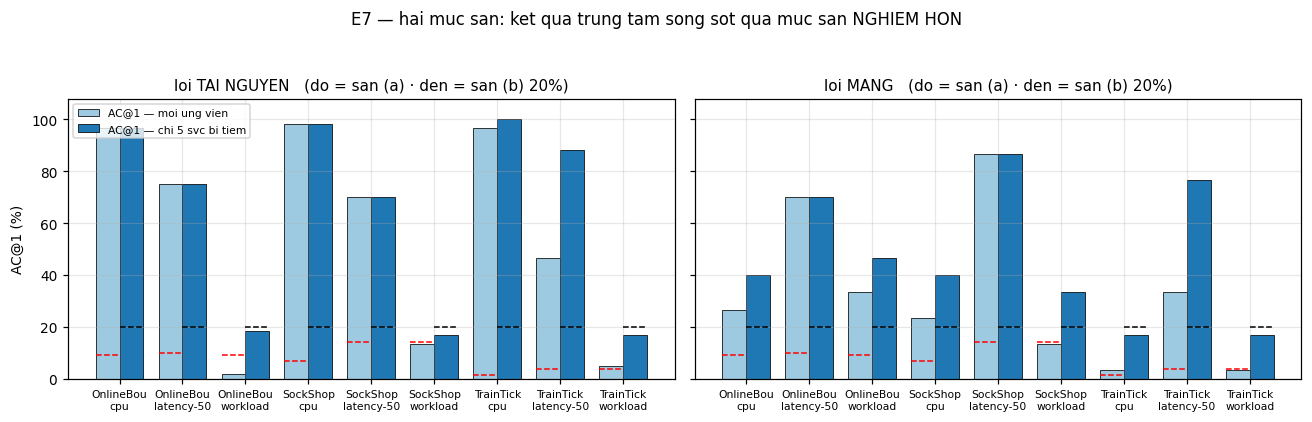

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, nhom in zip(axes, ['tai nguyen', 'mang']):
    sub = E7[E7.nhom_loi == nhom].sort_values(['he', 'tang'])
    lab = [f'{r.he[:9]}\n{r.tang}' for r in sub.itertuples()]
    x = np.arange(len(sub)); w = .38
    ax.bar(x - w/2, sub.ac1_all, w, label='AC@1 — moi ung vien', color='#9ecae1', edgecolor='k', lw=.5)
    ax.bar(x + w/2, sub.ac1_fs, w, label='AC@1 — chi 5 svc bi tiem', color='#1f77b4', edgecolor='k', lw=.5)
    for i, r in enumerate(sub.itertuples()):
        ax.plot([i - w, i], [r.floor_all]*2, 'r--', lw=1)
        ax.plot([i, i + w], [20, 20], 'k--', lw=1)
    ax.set_xticks(x); ax.set_xticklabels(lab, fontsize=7)
    ax.set_title(f'loi {nhom.upper()}   (do = san (a) · den = san (b) 20%)')
    ax.set_ylim(0, 108)
axes[0].set_ylabel('AC@1 (%)'); axes[0].legend(fontsize=7, loc='upper left')
plt.suptitle('E7 — hai muc san: ket qua trung tam song sot qua muc san NGHIEM HON', y=1.05)
plt.tight_layout(); plt.show()


### Đọc E7 — kết quả không chỉ sống, mà một phần **mạnh hơn**

**Hai phát biểu trung tâm sống sót:**

| | AC@1 (5 svc) | sàn | $p$ |
|---|---|---|---|
| tầng `cpu`, lỗi tài nguyên — Sock Shop | **98,3%** | 20% | $3\times10^{-40}$ |
| — Online Boutique | **96,7%** | 20% | $3\times10^{-38}$ |
| — Train Ticket | **100,0%** | 20% | $1\times10^{-42}$ |
| tầng `workload`, lỗi tài nguyên — SS / OB / TT | 16,7 / 18,3 / 16,7% | 20% | **0,63 / 0,87 / 0,63** |

Tiên đoán điểm **còn chắc hơn** ở mức sàn nghiêm: ba hệ, cả ba **không bác được** — và lần
này sàn là sàn *khó*, không phải sàn đều.

**Và lỗi mạng trên Train Ticket tốt hơn hẳn:** 33,3% → **76,7%**. Phần lớn "thất bại" của
tầng độ trễ ở Train Ticket là do **23 service không bao giờ bị tiêm** chen lên đầu — đúng
cái 2609.27069 cảnh báo. Hạn ứng viên vào tập hợp lệ thì tầng độ trễ đạt **76,7–88,3%**.

> **Mức sàn nào là mức sàn đúng cho phương pháp nào.** Phương pháp ở đây **không giám sát**:
> nó chỉ đọc độ lớn dịch chuyển metric, không bao giờ thấy một nhãn nào, nên **không thể**
> khai thác prior tập lỗi — mức sàn (a) là mức sàn đúng cho nó. Ngược lại, mọi baseline **có
> huấn luyện** trên RE2 phải được đo ở mức sàn (b). Báo cả hai cột là cách duy nhất để so
> sánh công bằng, và bài báo nên **trích và tiếp nhận** 2609.27069 thay vì bỏ qua.


## E8 — Quy mô khuếch đại chi phí lệch tầng

Nếu cơ chế ở E4 đúng (tranh chấp làm nhiễu tầng tài nguyên), thì **hệ càng lớn, tranh chấp
càng nhiều, lệch tầng càng đắt**. Kiểm bằng cách phân rã đóng góp của cơ chế đã fit thành
ba phần: nhu cầu (tier‑1), tranh chấp (backpressure), cục bộ (tier‑2).


In [19]:
S2 = nap('rq6_tier_decomposition_v2_summary.csv')
tong = S2.mean_tier1.abs() + S2.mean_backpressure.abs() + S2.mean_tier2.abs()
S2['ti phan nhu cau %']   = 100 * S2.mean_tier1.abs() / tong
S2['ti phan tranh chap %'] = 100 * S2.mean_backpressure.abs() / tong
S2['ti phan cuc bo %']     = 100 * S2.mean_tier2.abs() / tong

E8 = (S2.groupby('label')[['ti phan nhu cau %', 'ti phan tranh chap %', 'ti phan cuc bo %',
                           'strict_acc_pct']]
      .median().rename_axis('he'))
E8.insert(0, 'so node do', S2.groupby('label').size())
display(E8.round(1))
print('(cac ti phan la TRUNG VI theo node; do chinh xac quy gan cung la trung vi)\n')

print('--- TI PHAN NHU CAU DU DOAN DUOC DO CHINH XAC QUY GAN ---')
r, p = pearsonr(S2['ti phan nhu cau %'], S2.strict_acc_pct)
print(f'  Pearson r = {r:.3f}  (p = {p:.2g}, n = {len(S2)}, hai he)')
hi, lo = S2[S2['ti phan nhu cau %'] > 50], S2[S2['ti phan nhu cau %'] <= 50]
print(f'  nguong 50%: tren nguong -> do chinh xac trung vi {hi.strict_acc_pct.median():.0f}%  (n={len(hi)})')
print(f'              duoi nguong -> do chinh xac trung vi {lo.strict_acc_pct.median():.0f}%  (n={len(lo)})')
display(S2[['label', 'target', 'ti phan nhu cau %', 'strict_acc_pct']]
        .sort_values('ti phan nhu cau %').round(1).reset_index(drop=True))


,so node do,ti phan nhu cau %,ti phan tranh chap %,ti phan cuc bo %,strict_acc_pct
he,,,,,
SockShop,6,81.000,0.300,18.700,90.000
TrainTicket,4,15.700,33.900,46.400,0.000


(cac ti phan la TRUNG VI theo node; do chinh xac quy gan cung la trung vi)

--- TI PHAN NHU CAU DU DOAN DUOC DO CHINH XAC QUY GAN ---
  Pearson r = 0.957  (p = 1.5e-05, n = 10, hai he)
  nguong 50%: tren nguong -> do chinh xac trung vi 100%  (n=5)
              duoi nguong -> do chinh xac trung vi 0%  (n=5)


,label,target,ti phan nhu cau %,strict_acc_pct
0,SockShop,payment_cpu,2.800,0.000
1,TrainTicket,ts-seat-service_cpu,6.300,0.000
2,TrainTicket,ts-order-service_cpu,10.700,0.000
3,TrainTicket,ts-travel-service_cpu,20.800,0.000
4,TrainTicket,ts-user-service_cpu,48.100,60.000
5,SockShop,shipping_cpu,66.400,80.000
6,SockShop,user_cpu,80.000,100.000
7,SockShop,catalogue_cpu,82.000,60.000
8,SockShop,carts_cpu,92.200,100.000
9,SockShop,orders_cpu,99.300,100.000


> ⚠️ **E8 đang chờ chạy lại.** `rq6_tier_decomposition_v2*.csv` được tạo **12/09**, dùng
> đúng 4 node Train Ticket mà — theo E4b — **không còn** cha tranh chấp nào sau khi tập cạnh
> được sinh lại **18/09**. Nên mọi con số dưới đây, kể cả **Pearson 0,957** và **ngưỡng 50%**,
> **không tái lập được** trên trạng thái hiện tại của repo. `rq6_tier_decomposition_v3.py`
> chạy lại trên **ba hệ, mọi node `_cpu`**, và kiểm ngưỡng **ngoài mẫu** bằng
> leave‑one‑system‑out. Bảng dưới giữ lại để so sánh, **không** dùng làm bằng chứng.

### Đọc E8

| | Sock Shop (7 svc, 28 node) | Train Ticket (28 svc, 112 node) |
|---|---|---|
| tỉ phần **nhu cầu** | **81,0%** | **15,7%** |
| tỉ phần **tranh chấp** | 0,3% | **33,9%** |
| độ chính xác quy gán (trung vị) | **90,0%** | **0,0%** |

Hệ càng lớn, tranh chấp càng chiếm chỗ, tầng tài nguyên càng nhiễu → lệch tầng càng đắt.
Đây cũng là lý do một phương pháp xác nhận trên benchmark nhỏ **không chuyển được** sang hệ
lớn — và là một lời giải thích cho khoảng cách giữa kết quả benchmark và kết quả vận hành
trong văn liệu.

**Và tỉ phần đó dự đoán được độ chính xác:** Pearson **0,957** ($p = 1{,}5\times10^{-5}$,
$n = 10$, hai hệ). Ngưỡng 50% tách hoàn hảo trong mẫu. Tính được từ **cơ chế đã fit, không
cần đáp án**, nên dùng được lúc triển khai:

> **Tiêu chí khả nhận:** trước khi quy gán, đo tỉ phần nhu cầu. Dưới ngưỡng thì **từ chối
> trả lời** thay vì trả lời sai.

**Phải trung thực về chỗ này:** $n = 10$ node, **hai** điểm trên trục quy mô, và ngưỡng 50%
**fit trong mẫu**. Nên báo là **mô tả**, chưa phải ngưỡng vận hành. Kiểm trên tập giữ lại
là việc còn lại (Phần 6).


## E9 — Giao thức đánh giá: một bộ phát hiện phải có **đối chứng dương**

Mục này là một bài học phương pháp luận rút ra từ **lỗi của chính chúng tôi**, và nó đáng
vào bài vì nó lặp lại ở nhiều hệ thống phát hiện bất thường.

Bộ phát hiện rủi ro trong hệ gán cứng ngưỡng $z \ge 1{,}0$ (cảnh báo) / $z \ge 2{,}0$
(nghiêm trọng). Ta báo "zero false positive". Nhưng khi kiểm **đối chứng dương** — chạy bộ
phát hiện trên ca **có tiêm lỗi thật** — thì $z$ lớn nhất **quan sát được** chỉ là **0,448**.
Ngưỡng 1,0 **không đạt được**. Nên `flagged_rate = 0` ở **mọi** nhóm, kể cả nhóm bị tiêm, và
tuyên bố "zero false positive" là **rỗng**: nó đúng vì bộ phát hiện không bao giờ phát hiện gì.

Sửa: hiệu chỉnh ngưỡng từ **nửa null giữ lại**, rồi kiểm trên nửa còn lại.


In [20]:
R = nap('rq6_risk_threshold_recalibration.csv')
E9 = R.rename(columns={'z_warn': 'z canh bao', 'z_crit': 'z nghiem trong',
                       'fp_null_pct': 'FP tren null %', 'injection_self_pct': 'phat hien node bi tiem %',
                       'reachable_pct': 'gan co node ha nguon %', 'unreachable_pct': 'gan co node KHONG lien quan %'})
display(E9.round(2))
goc = E9.iloc[0]; chon = E9[(E9['FP tren null %'] == 0) & (E9['phat hien node bi tiem %'] == 100)].iloc[-1]
print(f"\nNGUONG GOC   z = {goc['z canh bao']}/{goc['z nghiem trong']}: "
      f"FP = {goc['FP tren null %']}%  NHUNG phat hien node bi tiem = {goc['phat hien node bi tiem %']}%")
print('  -> tuyen bo \"zero false positive\" la RONG: bo phat hien khong bao gio phat hien gi.')
print(f"NGUONG HIEU CHINH z = {chon['z canh bao']}/{chon['z nghiem trong']}: "
      f"FP = {chon['FP tren null %']}%  VA phat hien node bi tiem = {chon['phat hien node bi tiem %']}%")
print('  -> cung 0% FP, nhung tuyen bo gio KHONG RONG.')


,z canh bao,z nghiem trong,FP tren null %,phat hien node bi tiem %,gan co node ha nguon %,gan co node KHONG lien quan %
0,1.000,2.000,0.000,0.000,0.000,0.000
1,0.300,0.600,0.000,100.000,0.590,0.000
2,0.250,0.500,0.000,100.000,2.350,0.000
3,0.200,0.400,0.000,100.000,5.880,0.000
4,0.180,0.350,1.430,100.000,10.000,0.000
5,0.150,0.300,1.430,100.000,11.760,0.000
6,0.080,0.160,2.860,100.000,12.350,1.000



NGUONG GOC   z = 1.0/2.0: FP = 0.0%  NHUNG phat hien node bi tiem = 0.0%
  -> tuyen bo "zero false positive" la RONG: bo phat hien khong bao gio phat hien gi.
NGUONG HIEU CHINH z = 0.2/0.4: FP = 0.0%  VA phat hien node bi tiem = 100.0%
  -> cung 0% FP, nhung tuyen bo gio KHONG RONG.


### Đọc E9

| | $z$ ngưỡng | FP trên null | phát hiện node bị tiêm |
|---|---|---|---|
| gán cứng | 1,0 / 2,0 | 0% | **0%** ← tuyên bố rỗng |
| hiệu chỉnh từ nửa null | **0,20 / 0,40** | **0%** | **100%** |

> **Bài học, phát biểu tổng quát:** một chỉ số "zero false positive" **không có nghĩa** nếu
> không đi kèm **đối chứng dương**. Hai số phải báo cùng nhau, luôn luôn. Và ngưỡng phải
> hiệu chỉnh **từ dữ liệu null giữ lại**, không gán cứng theo trực giác.


---

# Phần 5 — Đóng góp, và định vị so với văn liệu

## 5.1 Sáu đóng góp

| | đóng góp | bằng chứng | dạng |
|---|---|---|---|
| **1** | **Nguyên lý khớp tầng** — định vị đúng khi và chỉ khi tầng soi = tầng nguyên nhân nằm | E1 (270 ca, 3 hệ) + E2 (hai chiều) | **lý thuyết + thực nghiệm** |
| **2** | **Cơ chế** — tranh chấp là `cpu → cpu`, chiếm 94,4% thang hiệu dụng; nó làm nhiễu tầng tài nguyên mà **không chạm** tầng nhu cầu | E4 (hệ số NNLS, độc lập Shapley) | **giải thích** |
| **3** | **Đơn vị quy gán** — lỗi mạng nằm ở **cạnh**; chấm theo **đường** nâng 33,3% → 80,0%, và sai số của chấm‑theo‑node **lớn theo độ sâu chuỗi gọi** | E6 | **lý thuyết + hệ quả giao thức** |
| **4** | **Chẩn đoán lại một thất bại trong văn liệu** — BARO (FSE'24) 98,3% vs 11,7% chỉ do cấu hình tầng; nên thất bại của quy gán nhân quả lan truyền là **lệch tầng**, không phải khuyết điểm phương pháp | E5 | **phát biểu về văn liệu** |
| **5** | **Tiêu chí khả nhận** — tỉ phần nhu cầu của cơ chế đã fit dự đoán độ chính xác quy gán (Pearson 0,957), tính được **không cần đáp án** → dùng được lúc triển khai | E8 | **công cụ** |
| **6** | **Hai bài học giao thức đánh giá** — (a) phải có đối chứng dương (E9); (b) phải báo **hai** mức sàn khi benchmark tiêm vào tập con (E7) | E9, E7 | **phương pháp luận** |

## 5.2 So với văn liệu gần nhất

| công trình | làm gì | khác gì với bài này |
|---|---|---|
| **RCAEval** (arXiv 2412.17015) | benchmark 3 hệ × 90 ca, **15 baseline**, AC@1/3/5, Avg@5, MRR | ta dùng **đúng** bộ đó, cùng quy mô; ta coi **tầng metric** là biến nghiên cứu mà benchmark coi là tiền xử lý |
| **BARO** (FSE'24) | thống kê bền `RobustScaler` + $\max\lvert z\rvert$ | ta **dùng nguyên văn** BARO làm một mức trong lưới E5, và cho thấy biến **tầng** lớn hơn biến **thuật toán** |
| **Interventional Shapley** (Budhathoki+, ICML'22) | quy gán bất thường bằng Shapley can thiệp | ta chẩn đoán lại thất bại của nó là **lệch tầng** (E4, E8), không phải khuyết điểm của Shapley |
| **arXiv 2609.27069** | audit RCAEval: lỗi chỉ tiêm vào 5 service → mức sàn thật là prior tập lỗi | ta **tiếp nhận** phê bình và chấm lại ở mức sàn nghiêm (E7); kết quả sống, và lỗi mạng còn tốt hơn. **Không giao nhau** với phát hiện tầng hay phát hiện đơn vị |
| **CausIL** | prohibited‑edge constraint cho đồ thị nhân quả microservice | ta dùng ý tưởng đó cho bảng mẫu cạnh (§2.1), và **thêm** cạnh `latency → latency` ngược |
| **ICP** (Peters+, JRSS‑B'16) | bất biến của phân phối điều kiện qua môi trường | ta dùng làm **nền lý thuyết cho can thiệp mềm** (§2.3b) — tiêm lỗi đổi cơ chế, không đặt cứng giá trị |

## 5.3 Khoảng cách còn lại so với chuẩn RCAEval

Trung thực về chỗ này, vì reviewer sẽ hỏi:

| | chuẩn RCAEval | bài này |
|---|---|---|
| hệ thống | 3 | ✅ **3** |
| ca lỗi | 270 (RE2 đầy đủ) | ✅ **270** |
| chỉ số | AC@1, AC@3, **AC@5, Avg@5, MRR** | ⚠️ có AC@1/AC@3; **thiếu** AC@5, Avg@5, MRR |
| baseline | **15** | ⚠️ **1** (BARO) — nhưng dùng trong lưới khớp, không chỉ so đầu‑đầu |

Hai việc để ngang chuẩn, cả hai **rẻ** vì hạng của service bị tiêm đã có sẵn trong mọi CSV:
(1) thêm AC@5 / Avg@5 / MRR — chỉ là đổi cách tổng hợp; (2) thêm 3–4 baseline từ
`phamquiluan/RCAEval` (CIRCA, RCD, MicroCause) vào lưới E5.


---

# Phần 6 — Giới hạn, viết trước thay vì chờ reviewer

| # | giới hạn | mức độ | cách giảm |
|---|---|---|---|
| **1** | **E1/E5/E6 là định vị lỗi đã xảy ra** (post‑hoc RCA), **không** phải dự phóng. Nó khử vòng tròn cho câu hỏi *tầng*, và không chứng minh gì về dự đoán tính năng mới | **cao** — phải nói ở Abstract | phát biểu đúng phạm vi |
| **2** | **Dạng chặt của điều kiện phạm vi SAI ở 2/3 hệ** (E3). Chỉ dạng độ lớn $\rho \ll 1$ đứng được | **trung** | đã xử lý: §2.4 phát biểu dạng độ lớn ngay từ đầu |
| **3** | **E8: $n = 10$ node, hai điểm trên trục quy mô**, ngưỡng 50% fit trong mẫu | **trung** | báo là mô tả; kiểm trên tập giữ lại; mở rộng soi NNLS từ 4 lên ≥10 node |
| **4** | **E2 phép (A) có vòng tròn cấu trúc** — cạnh `workload→workload` dựng từ đồ thị gọi, mà đáp án cũng là đồ thị gọi | **trung** | khử bằng phép (B) và phép (C); báo **cả ba**, không chỉ phép tốt nhất |
| **5** | **Cạnh tranh chấp là cạnh học**, không phải cạnh cấu trúc | thấp | đã kiểm an toàn OOD **trước** khi có các kết quả này; độ lớn xác nhận độc lập bằng NNLS (E4) |
| **6** | **Đồ thị gọi khai quá rộng**: Train Ticket có 17 service reachable theo đồ thị nhưng chỉ 10 theo dữ liệu quan sát (trùng 9) | thấp | một phần thất bại quy gán là do **đồ thị đầu vào**, không do phương pháp — phải nói rõ |
| **7** | **Chỉ 1 baseline** trong lưới khớp; thiếu AC@5 / Avg@5 / MRR | **trung** | §5.3 — cả hai đều rẻ |
| **9** | **Đồ thị thiếu cạnh `cpu → latency-50`** dù vật lý có (bão hoà CPU → hàng đợi dài) và dữ liệu xác nhận ($r_{\text{latency}} = 12$–$353$ khi tiêm lỗi CPU, 46,7–75,0% top‑1) | **trung** | §2.4b đã ghi; thêm mẫu cạnh đó và kiểm lại OOD là việc còn lại. Không làm sai kết quả nào ở trên vì tiên đoán điểm chỉ dựa vào tầng nhu cầu |
| **11** | **Hiệu ứng tầng không phổ quát** — ở Train Ticket, trộn tầng *giúp* BARO (+16,7 đ), và trên cùng tầng `cpu` MEANSHIFT hơn BARO **55 điểm**. "Tầng trội hơn thuật toán" chỉ đúng ở hệ ít cột | **cao** — phải vào Abstract | E5b đã phát biểu lại dạng có điều kiện; cần thêm baseline tác giả để biết điều kiện đó là gì |
| **12** | **86,6 điểm phụ thuộc chỉ số**: AC@1 +83,3 đ nhưng AC@5 chỉ +1,7 đ | **cao** | E1b/E5: neo vào AC@1 + MRR, biện minh bằng tính vận hành, và in cả năm chỉ số |
| **13** | **$R^2$ của cơ chế `_cpu` ≈ 0** ở đa số node (trung vị 0,08 / 0,07 / 0,02) | **cao** | E4b; tiêu chí ở E8 được tính trên mô hình gần như không giải thích gì — phải báo kèm $R^2$ |
| **14** | **Hai CSV bị stale**: `rq6_hop1_node_diagnostic.csv` và `rq6_tier_decomposition_v2*.csv` (12/09) dùng tập cạnh đã bị sinh lại 18/09; giao nhau của tập node = **rỗng** | **cao** | E4b thay E4; `rq6_tier_decomposition_v3.py` thay E8. **Phải khoá tập cạnh** (hash + commit) trước khi gửi bài |
| **15** | **Đối chứng âm trên mức sàn**: bộ không đọc telemetry đạt AC@1 = 20% ở Sock Shop `app` (sàn công thức 14,3%) vì service đầu bảng chữ cái tình cờ bị tiêm | trung | E5b đã đo; báo đối chứng âm cạnh mức sàn công thức |
| **10** | **Tiên đoán điểm chỉ đúng 2/3 ở mức sàn đều** — Online Boutique *dưới* mức sàn ($p = 0{,}041$) vì tầng `workload` ở đó gồm service không bao giờ bị tiêm | thấp | 3/3 ở mức sàn nghiêm (E7); phải báo **cả hai** mức sàn |
| **8** | **Mức sàn**: phương pháp không giám sát nên mức sàn (a) đúng cho nó, nhưng mức sàn (b) nghiêm hơn | thấp | đã xử lý: E7 báo **cả hai** |


---

# Phần 7 — Tái lập

Mọi con số trong notebook này được tính lại tại chỗ từ CSV. Để sinh lại **chính các CSV đó**
từ dữ liệu thô (`data/raw/RE2-SS`, `data/raw/RE2-OB`, `data/raw/trainticket`):

```bash
# (E1 + E3) ba tang + dieu kien pham vi, ba he
python papers/p2_khop_tang/experiments/rq6_three_layer_and_scope.py
#   -> rq6_three_layer_localization.csv, rq6_scope_condition_two_systems.csv

# (E2) chieu can thiep nhu cau, ba phep cham, khu vong tron
python papers/p2_khop_tang/experiments/rq6_localization_decircularized.py
#   -> rq6_localization_decircularized.csv

# (E4) co che: he so NNLS cua co che da fit
python papers/p2_khop_tang/experiments/rq6_hop1_node_diagnostic.py
#   -> rq6_hop1_node_diagnostic.csv

# (E5) luoi khop 2x2x2 voi BARO
python papers/p2_khop_tang/experiments/rq6_baro_matched_comparison.py
#   -> rq6_baro_matched_comparison.csv

# (E6) don vi quy gan: node / canh / duong
python papers/p2_khop_tang/experiments/rq6_attribution_unit.py
#   -> rq6_attribution_unit.csv

# (E7) hai muc san -- tra loi arXiv 2609.27069
python papers/p2_khop_tang/experiments/rq6_faultset_floor.py
#   -> rq6_faultset_floor.csv, rq6_faultset_floor_summary.csv

# (E1b) bo chi so chuan RCAEval -- chi doi cach tong hop, khong chay lai gi
python papers/p2_khop_tang/experiments/rq6_rcaeval_metrics.py
#   -> rq6_rcaeval_metrics_layers.csv, rq6_rcaeval_metrics_baro_grid.csv

# (E4b) co che tren 45 node, ba he  (THAY E4)
python papers/p2_khop_tang/experiments/rq6_mechanism_three_systems.py
#   -> rq6_mechanism_three_systems.csv, rq6_mechanism_three_systems_nodes.csv

# (E5b) luoi khop tong quat, ba he + doi chung am; --kiem-tai-lap doi chieu CSV cu
python papers/p2_khop_tang/experiments/rq6_matched_grid.py --kiem-tai-lap
#   -> rq6_matched_grid.csv, rq6_matched_grid_summary.csv
# va voi baseline CUA TAC GIA (sau khi clone RCAEval):
#   git clone https://github.com/phamquiluan/RCAEval && cd RCAEval && pip install -e .
#   RCAEVAL_PATH=<duong dan> python papers/p2_khop_tang/experiments/rq6_matched_grid.py

# (E8) phan ra tang + quy mo -- BAN v2 DA STALE (xem ghi chu o E8)
python papers/p2_khop_tang/experiments/rq6_tier_decomposition_v2.py
#   -> rq6_tier_decomposition_v2.csv, rq6_tier_decomposition_v2_summary.csv
# (E8 v3) THAY v2: ba he, moi node `_cpu`, kiem nguong NGOAI MAU
python papers/p2_khop_tang/experiments/rq6_tier_decomposition_v3.py --repeats=5
#   -> rq6_tier_decomposition_v3.csv, rq6_tier_decomposition_v3_nodes.csv

# (E9) hieu chinh nguong tu nua null giu lai
python papers/p2_khop_tang/experiments/recalibrate_risk_threshold.py
#   -> rq6_risk_threshold_recalibration.csv
```

Tài liệu đi kèm: `papers/p2_khop_tang/docs/PHAT_HIEN_KHOP_TANG.md` (chi tiết từng mục),
`papers/p2_khop_tang/docs/CAU_TRUC_BAI_BAO_XAI.md` (cấu trúc bài báo), `papers/p2_khop_tang/docs/POSITIONING_GROUNDING.md` (định vị).

Hai notebook còn lại: `01_du_lieu_do_thi_nhan_qua_va_du_doan.ipynb` (làm sạch dữ liệu tự đo,
dựng đồ thị, bộ dự phóng khả thi) và `02_quy_trinh_he_thong_va_thuc_nghiem.ipynb`
(quy trình hệ thống chạy từng bước, E0–E5).


In [21]:
import hashlib, datetime
print('kiem tinh toan ven — CSV nao duoc notebook nay dung:\n')
for ten in ['rq6_three_layer_localization.csv', 'rq6_scope_condition_two_systems.csv',
            'rq6_localization_decircularized.csv', 'rq6_hop1_node_diagnostic.csv',
            'rq6_baro_matched_comparison.csv', 'rq6_attribution_unit.csv',
            'rq6_faultset_floor.csv', 'rq6_faultset_floor_summary.csv',
            'rq6_tier_decomposition_v2_summary.csv', 'rq6_risk_threshold_recalibration.csv',
            'rq6_rcaeval_metrics_layers.csv', 'rq6_mechanism_three_systems_nodes.csv',
            'rq6_matched_grid_summary.csv']:
    p = RES / ten
    if not p.exists():
        print(f'  THIEU   {ten}'); continue
    b = p.read_bytes()
    print(f'  {hashlib.sha256(b).hexdigest()[:12]}  {len(b):>9,} B  '
          f'{datetime.datetime.fromtimestamp(p.stat().st_mtime):%Y-%m-%d %H:%M}  {ten}')


kiem tinh toan ven — CSV nao duoc notebook nay dung:

  5aae6a67cc2c     46,150 B  2026-10-01 15:36  rq6_three_layer_localization.csv
  6c183ee8eb78     13,871 B  2026-10-01 15:36  rq6_scope_condition_two_systems.csv
  1b587fcdb388     33,642 B  2026-09-30 08:44  rq6_localization_decircularized.csv
  5438c81ddf87      2,738 B  2026-09-12 23:42  rq6_hop1_node_diagnostic.csv
  4478bf63fb34     44,481 B  2026-09-30 08:53  rq6_baro_matched_comparison.csv
  de8982528764     11,807 B  2026-10-01 15:36  rq6_attribution_unit.csv
  ec938e5b4ffb    105,714 B  2026-10-01 21:04  rq6_faultset_floor.csv
  09e4ed5e6d2d      2,939 B  2026-10-01 21:04  rq6_faultset_floor_summary.csv
  98fd8a5682a6        685 B  2026-09-12 22:28  rq6_tier_decomposition_v2_summary.csv
  1429b1a9ff82        383 B  2026-09-30 07:50  rq6_risk_threshold_recalibration.csv
  ece4c7561e62      7,065 B  2026-10-01 21:04  rq6_rcaeval_metrics_layers.csv
  96e4e33c2b30      8,226 B  2026-10-01 20:09  rq6_mechanism_three_systems_nod